# House Price Prediction: Final Analysis

**Competition:** House Prices: Advanced Regression Techniques

## Analysis workflow

The analysis follows these steps:

1. understand the data and the scoring method;
2. identify data-quality and missing-value problems;
3. use EDA to guide cleaning and feature creation;
4. compare a basic linear model, Ridge and LASSO;
5. test several non-linear model directions;
6. combine models that make different errors;
7. shortlist candidate models using OOF validation; and
8. create and check the prediction files.

Log-RMSE is the main internal measure because it matches the competition metric.

## 1. Setup and portable file search


In [ ]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler
from sklearn.svm import SVR

from catboost import CatBoostRegressor

from xgboost import XGBRegressor

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")
sns.set_theme(style="whitegrid", context="notebook")

BLUE = "#3264A8"
ORANGE = "#E6863B"
GREEN = "#2E8B57"
RED = "#C44E52"
PURPLE = "#8172B3"
GREY = "#6B7280"

REQUIRED_FILES = ["train.csv", "test.csv", "sample_submission.csv", "data_description.txt"]

def find_project_dir():
    start = Path.cwd().resolve()
    candidates = []
    for folder in [start, *start.parents]:
        candidates.extend([folder, folder / "data", folder / "kaggle", folder / "upload"])

    for folder in dict.fromkeys(candidates):
        if folder.is_dir() and all((folder / name).exists() for name in REQUIRED_FILES):
            return folder

    raise FileNotFoundError(
        "Place train.csv, test.csv, sample_submission.csv "
        "and data_description.txt in the repository data folder."
    )

PROJECT_DIR = find_project_dir()
FIGURE_DIR = PROJECT_DIR / "figures" / "final_analysis"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "final_analysis"
SUBMISSION_DIR = PROJECT_DIR / "submissions"
for folder in [FIGURE_DIR, OUTPUT_DIR, SUBMISSION_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project folder: {PROJECT_DIR}")


## 2. Load and check the data


In [2]:
# keep_default_na=False prevents the valid word "None" from being read as missing.
# The source file uses "NA" to mark values that need review.
train = pd.read_csv(PROJECT_DIR / "train.csv", keep_default_na=False, na_values=["NA"])
test = pd.read_csv(PROJECT_DIR / "test.csv", keep_default_na=False, na_values=["NA"])
sample_submission = pd.read_csv(PROJECT_DIR / "sample_submission.csv")
data_description = (PROJECT_DIR / "data_description.txt").read_text(
    encoding="utf-8", errors="replace"
)

structure = pd.DataFrame({
    "Dataset": ["Training", "Test", "Sample submission"],
    "Rows": [len(train), len(test), len(sample_submission)],
    "Columns": [train.shape[1], test.shape[1], sample_submission.shape[1]],
    "Duplicate Id values": [
        train["Id"].duplicated().sum(),
        test["Id"].duplicated().sum(),
        sample_submission["Id"].duplicated().sum(),
    ],
})
display(structure)
display(train.head())


,Dataset,Rows,Columns,Duplicate Id values
0,Training,1460,81,0
1,Test,1459,80,0
2,Sample submission,1459,2,0


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.00000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.00000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.00000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.00000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Finding.** The training data contains 1,460 houses, 79 predictors, `Id` and `SalePrice`. The test data contains 1,459 houses with the same predictors but no sale price. No duplicate Id values were found.

**Decision.** Use `SalePrice` as the target and keep `Id` only for the final submission.


## 3. Review the target and evaluation metric


,SalePrice
count,"1,460.00000"
mean,"180,921.19589"
std,"79,442.50288"
min,"34,900.00000"
25%,"129,975.00000"
50%,"163,000.00000"
75%,"214,000.00000"
max,"755,000.00000"
skew,1.88288


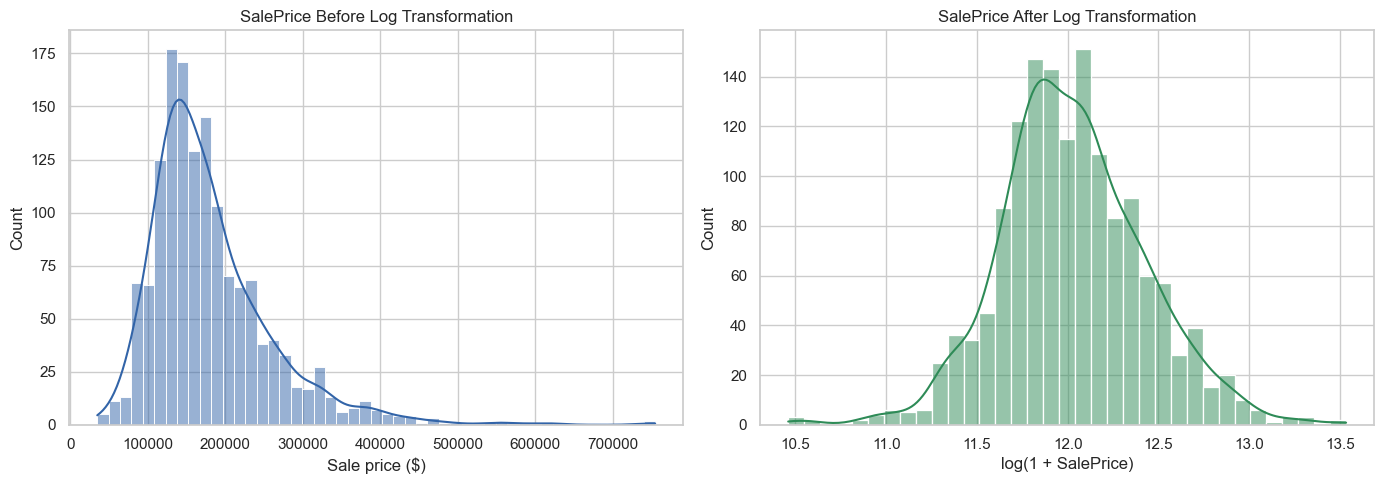

Original skewness: 1.883
Log-scale skewness: 0.121


In [3]:
target_summary = train["SalePrice"].describe().to_frame("SalePrice")
target_summary.loc["skew"] = train["SalePrice"].skew()
display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train["SalePrice"], kde=True, color=BLUE, ax=axes[0])
axes[0].set_title("SalePrice Before Log Transformation")
axes[0].set_xlabel("Sale price ($)")

sns.histplot(np.log1p(train["SalePrice"]), kde=True, color=GREEN, ax=axes[1])
axes[1].set_title("SalePrice After Log Transformation")
axes[1].set_xlabel("log(1 + SalePrice)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_target_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Original skewness: {train['SalePrice'].skew():.3f}")
print(f"Log-scale skewness: {np.log1p(train['SalePrice']).skew():.3f}")


**Finding.** Sale prices have a long right tail. The original skewness is about 1.88, while the log-scale skewness is about 0.12.

**Why it matters.** The competition uses RMSE on the logarithm of price. A few expensive houses should not control the model.

**Decision.** Train and validate the models using `log1p(SalePrice)`. Convert predictions back to dollars only when creating the submission.


## 4. Understand and handle missing values


,Train NA,Train NA (%),Test NA,Test NA (%)
PoolQC,1453,99.52055,1456,99.79438
MiscFeature,1406,96.30137,1408,96.50446
Alley,1369,93.76712,1352,92.66621
Fence,1179,80.75342,1169,80.12337
FireplaceQu,690,47.26027,730,50.03427
LotFrontage,259,17.73973,227,15.55860
GarageYrBlt,81,5.54795,78,5.34613
GarageType,81,5.54795,76,5.20905
GarageFinish,81,5.54795,78,5.34613
GarageCond,81,5.54795,78,5.34613


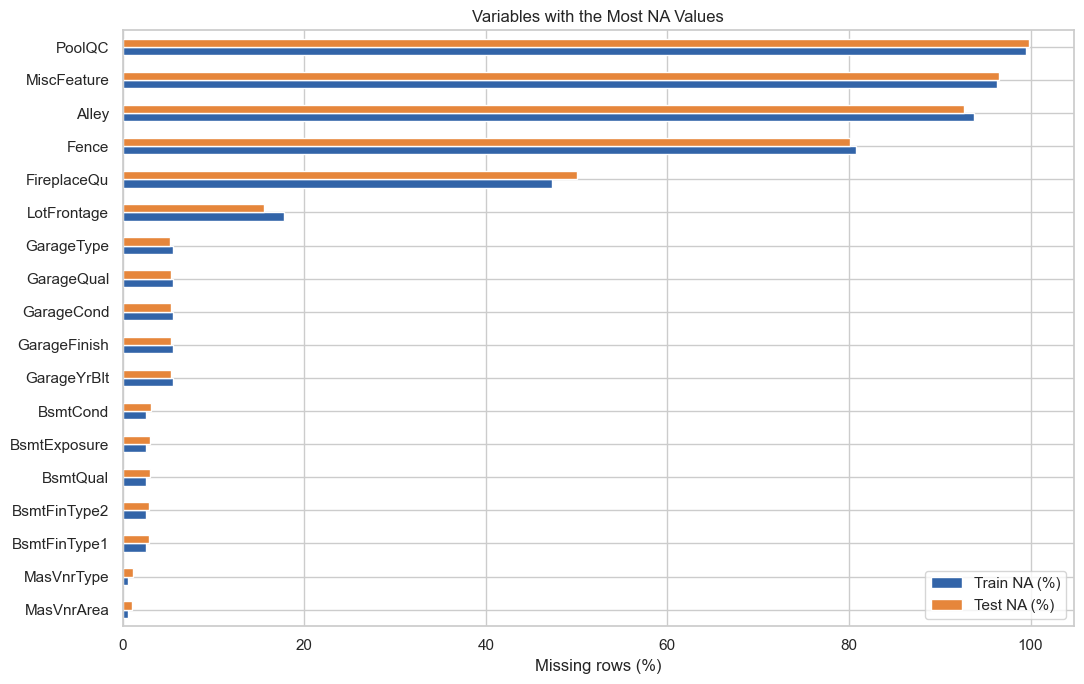

,Variable,Meaning in data description,Found in file
0,PoolQC,NA No Pool,True
1,Alley,NA No alley access,True
2,Fence,NA No Fence,True
3,FireplaceQu,NA No Fireplace,True
4,GarageType,NA No Garage,True
5,BsmtQual,NA No Basement,True


,Variable group,Meaning,Treatment
0,"Pool, alley, fence and fireplace categories",The feature is not present,"Use ""None"""
1,Garage and basement categories,The feature is not present,"Use ""None"""
2,"Garage, basement and masonry sizes",The related feature is not present,Use 0
3,Other numeric variables,A value was not recorded,Use the training-fold median
4,Other category variables,A value was not recorded,Use the training-fold most common value


In [4]:
all_columns = train.drop(columns="SalePrice").columns
missing_table = pd.DataFrame({
    "Train NA": train[all_columns].isna().sum(),
    "Train NA (%)": 100 * train[all_columns].isna().mean(),
    "Test NA": test[all_columns].isna().sum(),
    "Test NA (%)": 100 * test[all_columns].isna().mean(),
})
missing_table["Highest NA (%)"] = missing_table[["Train NA (%)", "Test NA (%)"]].max(axis=1)
missing_table = missing_table[missing_table["Highest NA (%)"] > 0].sort_values(
    "Highest NA (%)", ascending=False
)
display(missing_table.drop(columns="Highest NA (%)"))

plot_missing = missing_table.head(18).sort_values("Highest NA (%)")
plot_missing[["Train NA (%)", "Test NA (%)"]].plot.barh(
    figsize=(11, 7), color=[BLUE, ORANGE]
)
plt.xlabel("Missing rows (%)")
plt.ylabel("")
plt.title("Variables with the Most NA Values")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

# Confirm examples stated directly in data_description.txt.
normalized_description = " ".join(data_description.split())
description_evidence = pd.DataFrame([
    ["PoolQC", "NA No Pool", "NA No Pool" in normalized_description],
    ["Alley", "NA No alley access", "NA No alley access" in normalized_description],
    ["Fence", "NA No Fence", "NA No Fence" in normalized_description],
    ["FireplaceQu", "NA No Fireplace", "NA No Fireplace" in normalized_description],
    ["GarageType", "NA No Garage", "NA No Garage" in normalized_description],
    ["BsmtQual", "NA No Basement", "NA No Basement" in normalized_description],
], columns=["Variable", "Meaning in data description", "Found in file"])
display(description_evidence)

missing_policy = pd.DataFrame([
    ["Pool, alley, fence and fireplace categories", "The feature is not present", 'Use "None"'],
    ["Garage and basement categories", "The feature is not present", 'Use "None"'],
    ["Garage, basement and masonry sizes", "The related feature is not present", "Use 0"],
    ["Other numeric variables", "A value was not recorded", "Use the training-fold median"],
    ["Other category variables", "A value was not recorded", "Use the training-fold most common value"],
], columns=["Variable group", "Meaning", "Treatment"])
display(missing_policy)
missing_table.drop(columns="Highest NA (%)").to_csv(
    OUTPUT_DIR / "missing_value_audit.csv"
)


**Finding.** The training and test sets have missing values in several of the same variables. The checks against `data_description.txt` confirm that NA can mean no pool, alley, fence, fireplace, garage or basement. These values describe the house and are not ordinary data errors.

**Decision.** Treat absence as useful information. Use `"None"` for missing facility categories and `0` for related sizes or counts. Use median or most-common-value filling only when information is truly unrecorded. These fill values are learned from the training part of each validation fold.


## 5. Use EDA to guide features and outlier treatment


### 5.1 Review all numerical distributions


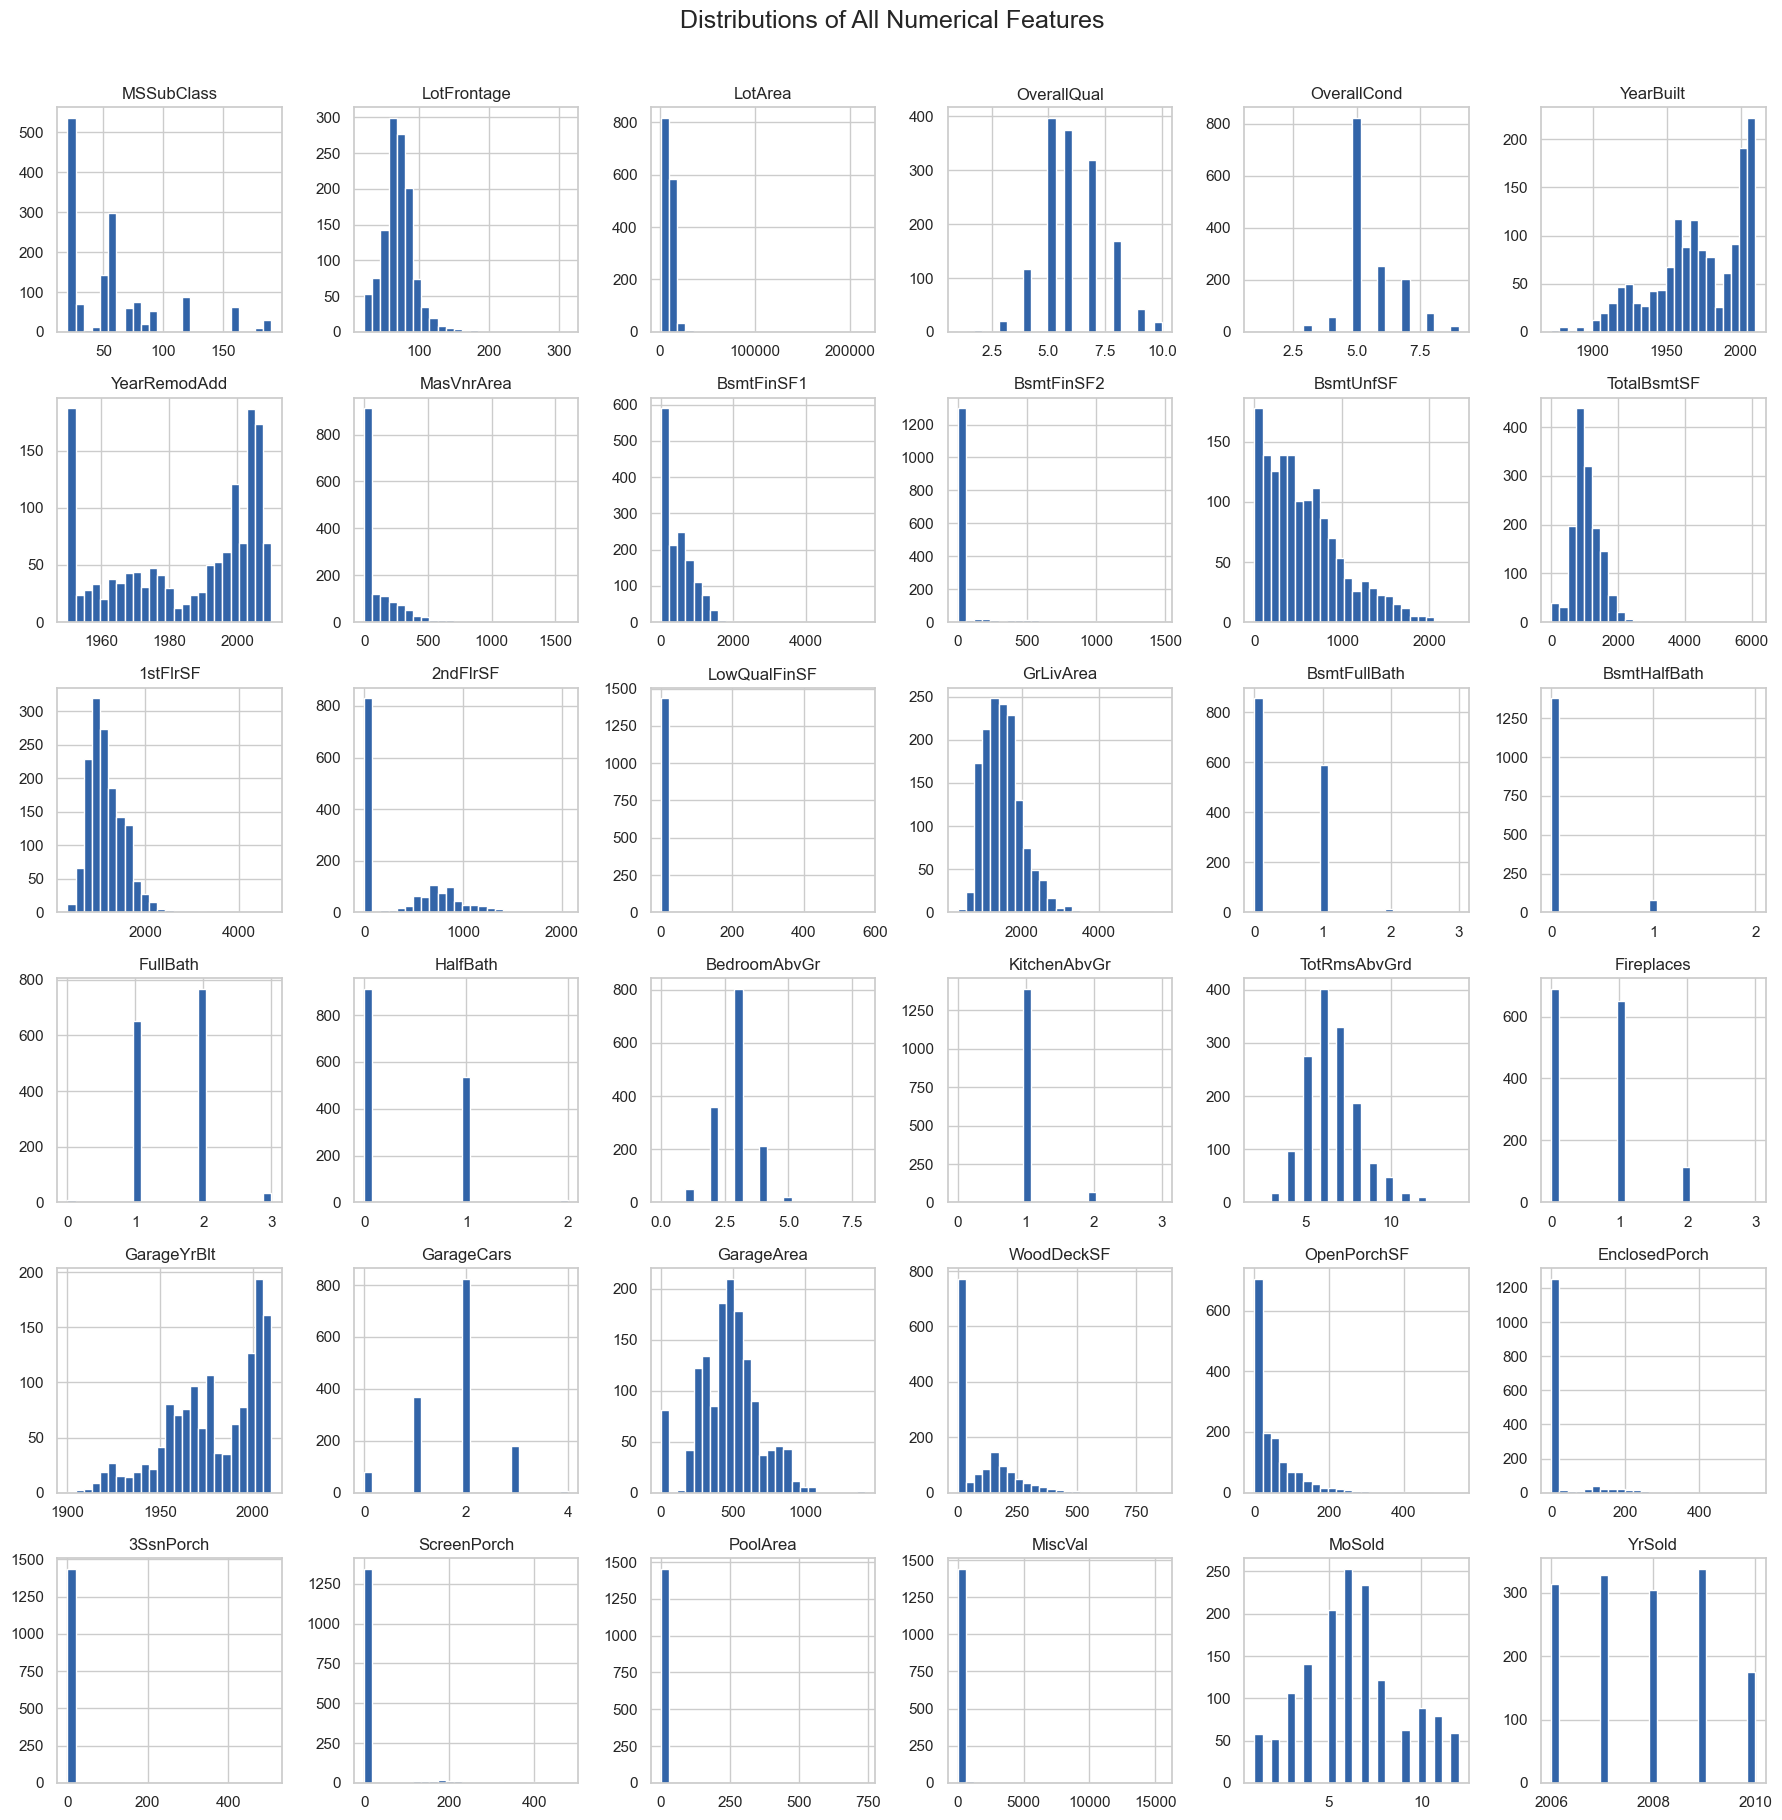

,Missing (%),Zero values (%),Skewness,Unique values
MiscVal,0.00000,96.43836,24.47679,21
PoolArea,0.00000,99.52055,14.82837,8
LotArea,0.00000,0.00000,12.20769,1073
3SsnPorch,0.00000,98.35616,10.30434,20
LowQualFinSF,0.00000,98.21918,9.01134,24
KitchenAbvGr,0.00000,0.06849,4.48840,4
BsmtFinSF2,0.00000,88.56164,4.25526,144
ScreenPorch,0.00000,92.05479,4.12221,76
BsmtHalfBath,0.00000,94.38356,4.10340,3
EnclosedPorch,0.00000,85.75342,3.08987,120


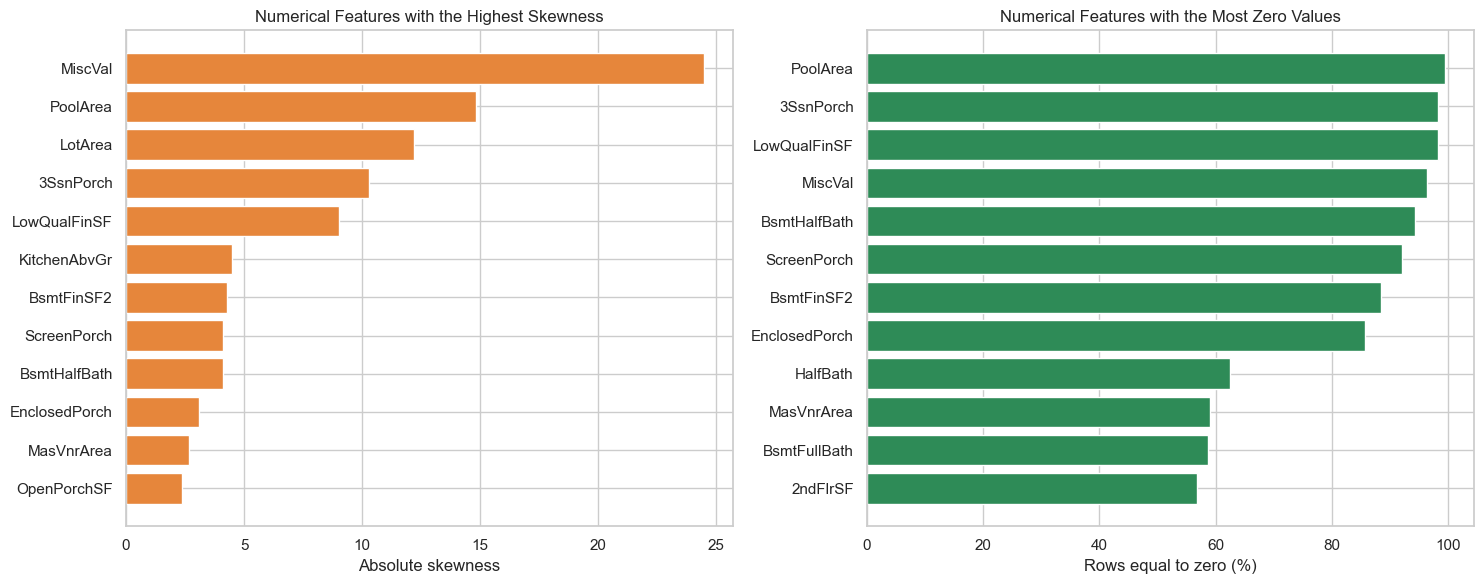

In [5]:
numerical_features = (
    train.select_dtypes(exclude="object")
    .drop(columns=["Id", "SalePrice"])
)

numerical_features.hist(
    bins=25,
    figsize=(18, 18),
    layout=(6, 6),
    color=BLUE,
    edgecolor="white",
)
plt.suptitle("Distributions of All Numerical Features", fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_all_numeric_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

numerical_profile = pd.DataFrame({
    "Missing (%)": 100 * numerical_features.isna().mean(),
    "Zero values (%)": 100 * numerical_features.eq(0).mean(),
    "Skewness": numerical_features.skew(),
    "Unique values": numerical_features.nunique(),
})
numerical_profile["Absolute skewness"] = numerical_profile["Skewness"].abs()
numerical_profile = numerical_profile.sort_values("Absolute skewness", ascending=False)
display(numerical_profile.drop(columns="Absolute skewness"))
numerical_profile.to_csv(OUTPUT_DIR / "numerical_feature_profile.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
high_skew = numerical_profile.head(12).sort_values("Absolute skewness")
axes[0].barh(high_skew.index, high_skew["Absolute skewness"], color=ORANGE)
axes[0].set_title("Numerical Features with the Highest Skewness")
axes[0].set_xlabel("Absolute skewness")

high_zero = numerical_profile.sort_values("Zero values (%)", ascending=False).head(12)
high_zero = high_zero.sort_values("Zero values (%)")
axes[1].barh(high_zero.index, high_zero["Zero values (%)"], color=GREEN)
axes[1].set_title("Numerical Features with the Most Zero Values")
axes[1].set_xlabel("Rows equal to zero (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_skewness_and_zero_values.png", dpi=200, bbox_inches="tight")
plt.show()


**Findings.** Several area variables have long right tails. Other variables, including pool, porch and second-floor area, contain many zero values because most houses do not have that feature.

**Actions.** Keep the log transformation for strongly skewed numerical inputs. Test simple yes/no variables for selected features with many zero values. These indicators may help LASSO separate "not present" from "present but small."


### 5.2 Review important relationships and unusual houses


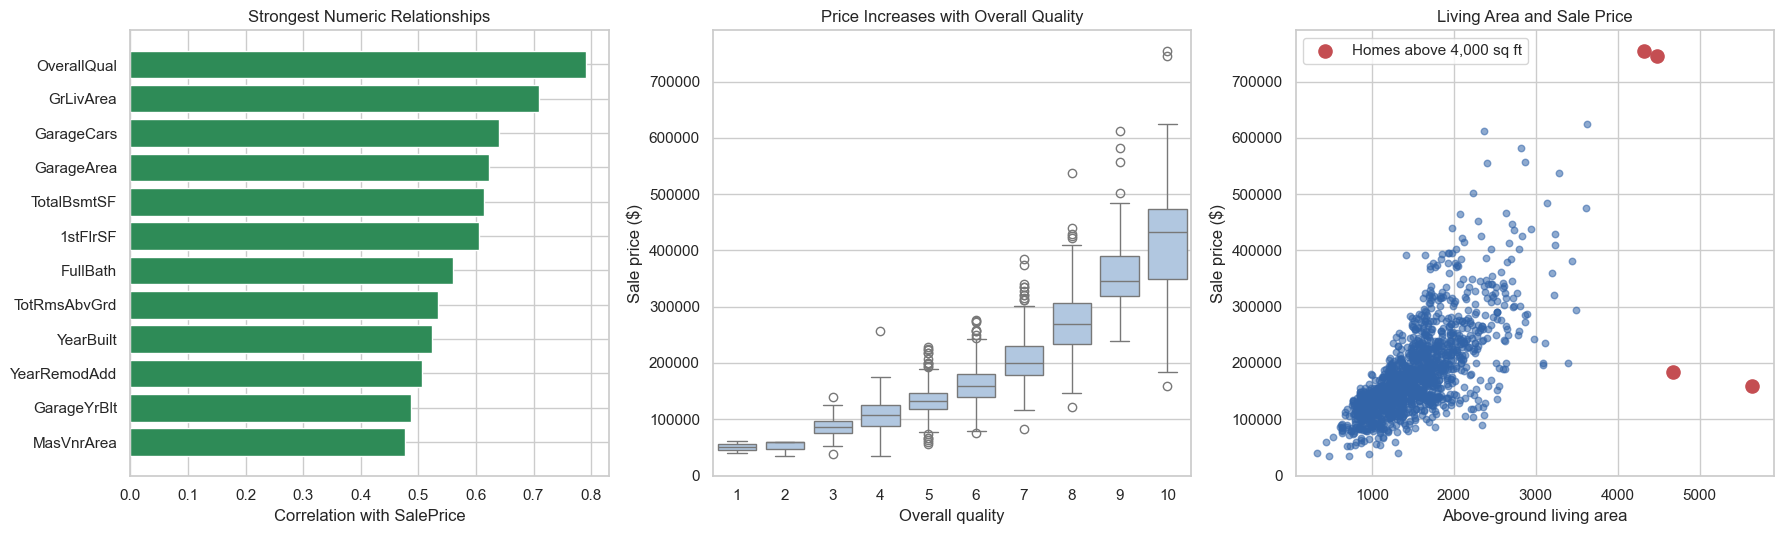

,Id,GrLivArea,OverallQual,Neighborhood,SalePrice
523,524,4676,10,Edwards,184750
691,692,4316,10,NoRidge,755000
1182,1183,4476,10,NoRidge,745000
1298,1299,5642,10,Edwards,160000


In [6]:
all_numeric_correlations = (
    train.select_dtypes(exclude="object")
    .corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
)
strongest_names = all_numeric_correlations.abs().nlargest(12).index
numeric_correlations = all_numeric_correlations.loc[strongest_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
sorted_correlations = numeric_correlations.sort_values()
correlation_colors = [GREEN if value >= 0 else RED for value in sorted_correlations]
axes[0].barh(
    sorted_correlations.index,
    sorted_correlations.values,
    color=correlation_colors,
)
axes[0].set_title("Strongest Numeric Relationships")
axes[0].set_xlabel("Correlation with SalePrice")

sns.boxplot(data=train, x="OverallQual", y="SalePrice", color="#A9C7E8", ax=axes[1])
axes[1].set_title("Price Increases with Overall Quality")
axes[1].set_xlabel("Overall quality")
axes[1].set_ylabel("Sale price ($)")

extreme_mask = train["GrLivArea"] > 4000
axes[2].scatter(train["GrLivArea"], train["SalePrice"], alpha=0.55, s=22, color=BLUE)
axes[2].scatter(
    train.loc[extreme_mask, "GrLivArea"],
    train.loc[extreme_mask, "SalePrice"],
    s=90, color=RED, label="Homes above 4,000 sq ft",
)
axes[2].set_title("Living Area and Sale Price")
axes[2].set_xlabel("Above-ground living area")
axes[2].set_ylabel("Sale price ($)")
axes[2].legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_key_relationships.png", dpi=200, bbox_inches="tight")
plt.show()

display(train.loc[extreme_mask, ["Id", "GrLivArea", "OverallQual", "Neighborhood", "SalePrice"]])


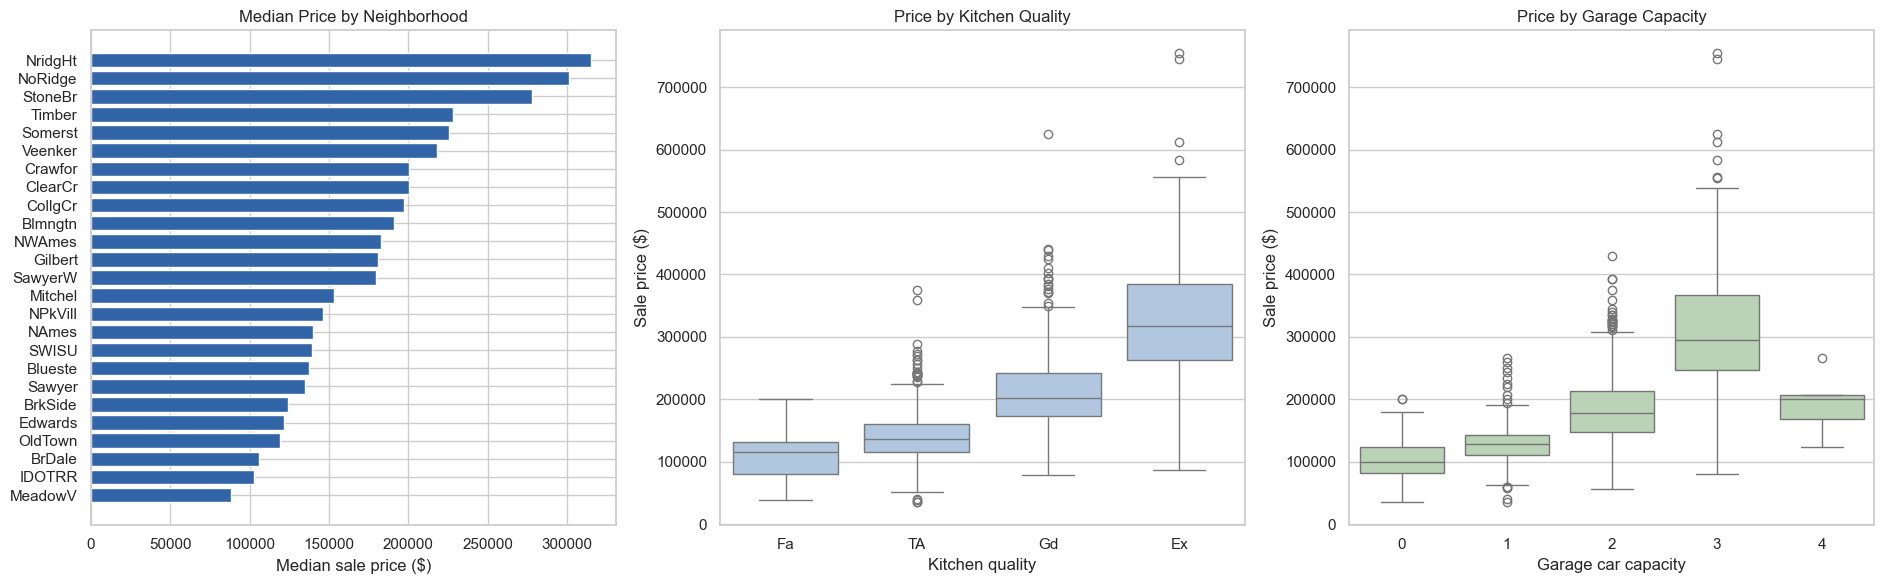

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

neighborhood_price = train.groupby("Neighborhood")["SalePrice"].median().sort_values()
axes[0].barh(neighborhood_price.index, neighborhood_price.values, color=BLUE)
axes[0].set_title("Median Price by Neighborhood")
axes[0].set_xlabel("Median sale price ($)")

kitchen_order = train.groupby("KitchenQual")["SalePrice"].median().sort_values().index
sns.boxplot(
    data=train, x="KitchenQual", y="SalePrice",
    order=kitchen_order, color="#A9C7E8", ax=axes[1],
)
axes[1].set_title("Price by Kitchen Quality")
axes[1].set_xlabel("Kitchen quality")
axes[1].set_ylabel("Sale price ($)")

sns.boxplot(data=train, x="GarageCars", y="SalePrice", color="#B7D7B0", ax=axes[2])
axes[2].set_title("Price by Garage Capacity")
axes[2].set_xlabel("Garage car capacity")
axes[2].set_ylabel("Sale price ($)")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_category_relationships.png", dpi=200, bbox_inches="tight")
plt.show()


**Findings.** Quality, living area, garage capacity, basement area and first-floor area have strong relationships with price. Neighborhood and kitchen quality also separate lower- and higher-priced houses. Four training houses have more than 4,000 square feet of above-ground living area.

**Actions.** Create a small set of features that combine area, quality, bathrooms and house age. The provided data description does not give an outlier rule. De Cock's original Ames Housing paper recommends considering the removal of houses above 4,000 square feet. Section 8 tests this predictor-only rule against keeping every row before making a decision.


### 5.3 Review categorical variables


,Number of levels,Most common level (%),Missing (%)
Neighborhood,25,15.41096,0.00000
Exterior2nd,16,34.52055,0.00000
Exterior1st,15,35.27397,0.00000
Condition1,9,86.30137,0.00000
SaleType,9,86.78082,0.00000
HouseStyle,8,49.72603,0.00000
RoofMatl,8,98.21918,0.00000
Condition2,8,98.97260,0.00000
Functional,7,93.15068,0.00000
BsmtFinType2,6,88.32630,2.60274


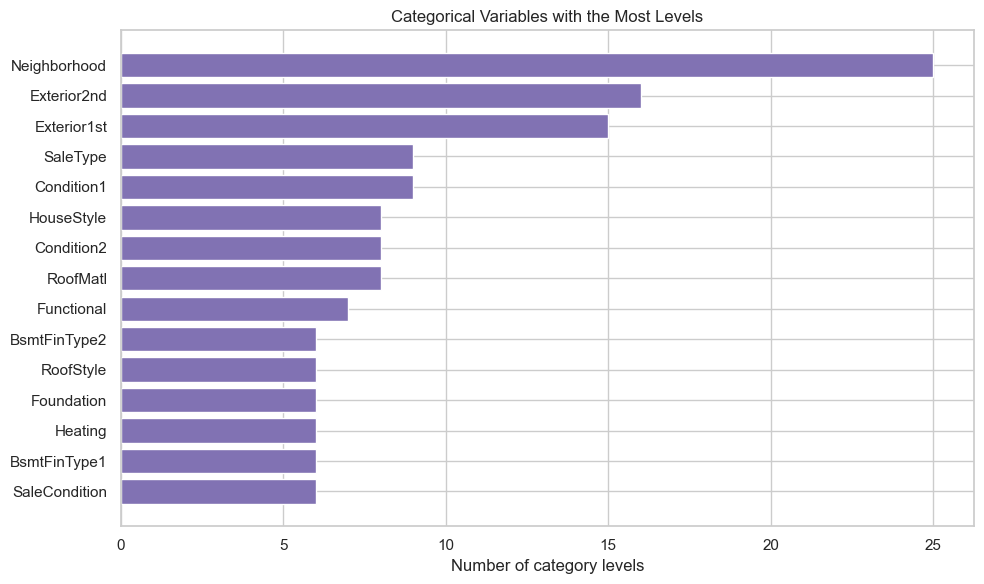

In [8]:
categorical_features = train.select_dtypes(include="object")
categorical_profile = pd.DataFrame({
    "Number of levels": categorical_features.nunique(dropna=True),
    "Most common level (%)": 100 * categorical_features.apply(
        lambda column: column.value_counts(normalize=True, dropna=True).iloc[0]
    ),
    "Missing (%)": 100 * categorical_features.isna().mean(),
}).sort_values("Number of levels", ascending=False)
display(categorical_profile)

plot_categories = categorical_profile.head(15).sort_values("Number of levels")
plt.figure(figsize=(10, 6))
plt.barh(plot_categories.index, plot_categories["Number of levels"], color=PURPLE)
plt.xlabel("Number of category levels")
plt.ylabel("")
plt.title("Categorical Variables with the Most Levels")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_categorical_levels.png", dpi=200, bbox_inches="tight")
plt.show()
categorical_profile.to_csv(OUTPUT_DIR / "categorical_feature_profile.csv")


**Finding.** The data contains many category variables, and some have many different levels. Neighborhood is also strongly related to price.

**Decision.** Convert categories into separate yes/no columns for the linear and Gradient Boosting models. Keep the original category labels for CatBoost, which is designed to handle them directly.


## 6. Clean the data and create useful features


In [9]:
QUALITY_ORDER = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ORDINAL_MAPS = {
    "ExterQual": QUALITY_ORDER,
    "ExterCond": QUALITY_ORDER,
    "BsmtQual": QUALITY_ORDER,
    "BsmtCond": QUALITY_ORDER,
    "HeatingQC": QUALITY_ORDER,
    "KitchenQual": QUALITY_ORDER,
    "FireplaceQu": QUALITY_ORDER,
    "GarageQual": QUALITY_ORDER,
    "GarageCond": QUALITY_ORDER,
    "PoolQC": QUALITY_ORDER,
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "Functional": {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "LotShape": {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "LandSlope": {"Sev": 0, "Mod": 1, "Gtl": 2},
    "Utilities": {"ELO": 0, "NoSeWa": 1, "NoSewr": 2, "AllPub": 3},
}

def clean_and_engineer(
    data, use_ordinal_numbers=False,
    add_zero_indicators=False, add_targeted_features=False,
):
    data = data.copy().drop(columns=["Id"], errors="ignore")

    absent_categories = [
        "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
        "GarageType", "GarageFinish", "GarageQual", "GarageCond",
        "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
        "BsmtFinType2", "MasVnrType",
    ]
    absent_numbers = [
        "GarageYrBlt", "GarageArea", "GarageCars", "BsmtFinSF1",
        "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath",
        "BsmtHalfBath", "MasVnrArea",
    ]
    for column in absent_categories:
        data[column] = data[column].fillna("None")
    for column in absent_numbers:
        data[column] = data[column].fillna(0)

    data["Functional"] = data["Functional"].fillna("Typ")
    data.loc[data["GarageYrBlt"] > data["YrSold"] + 1, "GarageYrBlt"] = np.nan

    # Features suggested by the EDA.
    data["TotalSF"] = data["TotalBsmtSF"] + data["1stFlrSF"] + data["2ndFlrSF"]
    data["TotalBathrooms"] = (
        data["FullBath"] + 0.5 * data["HalfBath"]
        + data["BsmtFullBath"] + 0.5 * data["BsmtHalfBath"]
    )
    data["TotalPorchSF"] = (
        data["WoodDeckSF"] + data["OpenPorchSF"] + data["EnclosedPorch"]
        + data["3SsnPorch"] + data["ScreenPorch"]
    )
    data["HouseAge"] = (data["YrSold"] - data["YearBuilt"]).clip(lower=0)
    data["RemodelAge"] = (data["YrSold"] - data["YearRemodAdd"]).clip(lower=0)
    data["GarageAge"] = np.where(
        data["GarageYrBlt"] > 0,
        (data["YrSold"] - data["GarageYrBlt"]).clip(lower=0),
        0,
    )
    data["OverallQualityArea"] = data["OverallQual"] * data["GrLivArea"]
    data["QualityTotalSF"] = data["OverallQual"] * data["TotalSF"]
    data["GarageScore"] = data["GarageCars"] * data["GarageArea"]
    data["BathroomLivingArea"] = data["TotalBathrooms"] * data["GrLivArea"]
    data["HasGarage"] = (data["GarageArea"] > 0).astype(str)
    data["HasBasement"] = (data["TotalBsmtSF"] > 0).astype(str)
    data["HasFireplace"] = (data["Fireplaces"] > 0).astype(str)
    data["HasPool"] = (data["PoolArea"] > 0).astype(str)
    data["WasRemodeled"] = (data["YearRemodAdd"] != data["YearBuilt"]).astype(str)

    # These features are tested later only if residual plots support the idea.
    if add_targeted_features:
        basement_quality = data["BsmtQual"].map(QUALITY_ORDER).fillna(0)
        garage_quality = data["GarageQual"].map(QUALITY_ORDER).fillna(0)
        data["OverallQualSquared"] = data["OverallQual"] ** 2
        data["HouseAgeSquared"] = data["HouseAge"] ** 2
        data["BasementValue"] = data["TotalBsmtSF"] * basement_quality
        data["GarageValue"] = data["GarageArea"] * garage_quality

    # Additional LASSO features suggested by the distribution review.
    if add_zero_indicators:
        indicator_sources = {
            "Has2ndFloor": "2ndFlrSF",
            "HasMasVnr": "MasVnrArea",
            "HasWoodDeck": "WoodDeckSF",
            "HasOpenPorch": "OpenPorchSF",
            "HasEnclosedPorch": "EnclosedPorch",
            "HasScreenPorch": "ScreenPorch",
        }
        for new_column, source_column in indicator_sources.items():
            data[new_column] = (data[source_column] > 0).astype(str)

    if use_ordinal_numbers:
        for column, mapping in ORDINAL_MAPS.items():
            data[column] = data[column].map(mapping)

    for column in ["MSSubClass", "YrSold", "MoSold"]:
        data[column] = data[column].astype(str)

    return data

X_linear_base = clean_and_engineer(
    train.drop(columns="SalePrice"), use_ordinal_numbers=False,
)
X_linear_test_base = clean_and_engineer(
    test, use_ordinal_numbers=False,
)
X_linear_eda = clean_and_engineer(
    train.drop(columns="SalePrice"), use_ordinal_numbers=False,
    add_zero_indicators=True,
)
X_linear_test_eda = clean_and_engineer(
    test, use_ordinal_numbers=False, add_zero_indicators=True,
)
X_linear = X_linear_base
X_linear_test = X_linear_test_base
X_tree = clean_and_engineer(train.drop(columns="SalePrice"), use_ordinal_numbers=True)
X_tree_test = clean_and_engineer(test, use_ordinal_numbers=True)
y_log = np.log1p(train["SalePrice"]).to_numpy()

feature_summary = pd.DataFrame([
    ["LASSO and Ridge", "Original engineered features", X_linear_base.shape[1]],
    ["LASSO EDA test", "Adds six yes/no indicators from the distribution review", X_linear_eda.shape[1]],
    ["Gradient Boosting", "Ordered quality levels use numbers; other categories use one-hot", X_tree.shape[1]],
    ["CatBoost", "Ordered levels use numbers; remaining categories stay as categories", X_tree.shape[1]],
], columns=["Model group", "Feature treatment", "Input columns before encoding"])
display(feature_summary)

cleaning_summary = pd.DataFrame([
    ["Training", int(train.drop(columns="SalePrice").isna().sum().sum()),
     int(X_linear_base.isna().sum().sum())],
    ["Test", int(test.isna().sum().sum()),
     int(X_linear_test_base.isna().sum().sum())],
], columns=["Dataset", "NA before meaning-based cleaning", "NA left for fold imputation"])
display(cleaning_summary)

future_garage_years = (
    (train["GarageYrBlt"] > train["YrSold"] + 1).sum()
    + (test["GarageYrBlt"] > test["YrSold"] + 1).sum()
)
print(f"Future garage years changed to missing for fold imputation: {future_garage_years}")


,Model group,Feature treatment,Input columns before encoding
0,LASSO and Ridge,Original engineered features,94
1,LASSO EDA test,Adds six yes/no indicators from the distributi...,100
2,Gradient Boosting,Ordered quality levels use numbers; other cate...,94
3,CatBoost,Ordered levels use numbers; remaining categori...,94


,Dataset,NA before meaning-based cleaning,NA left for fold imputation
0,Training,6965,260
1,Test,7000,238


Future garage years changed to missing for fold imputation: 1


**Result.** Meaning-based cleaning removes the NA values that represent an absent feature. The smaller number left afterward represents unrecorded or inconsistent values and is filled inside each training fold.

**Decision.** LASSO and Ridge receive one-hot category columns because linear models should not assume that category codes are evenly spaced. Gradient Boosting receives numeric codes only for variables with a clear order, such as poor to excellent. CatBoost can work directly with the remaining categories.


## 7. Build fold-safe preprocessing and validation


In [10]:
def build_preprocessor(features):
    numeric_columns = features.select_dtypes(exclude="object").columns.tolist()
    category_columns = features.select_dtypes(include="object").columns.tolist()

    # Log-transform strongly skewed numeric predictors identified during EDA.
    skewed_columns = (
        features[numeric_columns].skew().abs()
        .loc[lambda values: values > 0.75]
        .index.tolist()
    )
    regular_columns = [column for column in numeric_columns if column not in skewed_columns]

    return ColumnTransformer([
        ("skewed numbers", Pipeline([
            ("fill", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", RobustScaler()),
        ]), skewed_columns),
        ("other numbers", Pipeline([
            ("fill", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
        ]), regular_columns),
        ("categories", Pipeline([
            ("fill", SimpleImputer(strategy="most_frequent")),
            ("one-hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), category_columns),
    ])

def run_sklearn_cv(
    features, test_features, make_model, cv_seed, excluded_rows=None
):
    folds = KFold(n_splits=5, shuffle=True, random_state=cv_seed)
    oof_prediction = np.zeros(len(features))
    test_predictions = []

    for train_index, valid_index in folds.split(features):
        fit_index = train_index
        if excluded_rows is not None:
            fit_index = train_index[~excluded_rows.iloc[train_index].to_numpy()]

        # Skewed columns and all fill/scale values are learned from this fold only.
        preprocessor = build_preprocessor(features.iloc[fit_index])
        X_fit = preprocessor.fit_transform(features.iloc[fit_index])
        X_valid = preprocessor.transform(features.iloc[valid_index])
        X_test_ready = preprocessor.transform(test_features)

        model = make_model(cv_seed)
        model.fit(X_fit, y_log[fit_index])
        oof_prediction[valid_index] = model.predict(X_valid)
        test_predictions.append(model.predict(X_test_ready))

    return oof_prediction, np.mean(test_predictions, axis=0)

def log_rmse(actual, predicted):
    return root_mean_squared_error(actual, predicted)

def regression_metrics(actual_log, predicted_log):
    '''Calculate OOF metrics on both log and dollar scales.'''
    actual_price = np.expm1(actual_log)
    predicted_price = np.expm1(predicted_log)
    return {
        "Log RMSE": root_mean_squared_error(actual_log, predicted_log),
        "Log MSE": mean_squared_error(actual_log, predicted_log),
        "Log MAE": mean_absolute_error(actual_log, predicted_log),
        "Log R²": r2_score(actual_log, predicted_log),
        "Dollar RMSE": root_mean_squared_error(actual_price, predicted_price),
        "Dollar MSE": mean_squared_error(actual_price, predicted_price),
        "Dollar MAE": mean_absolute_error(actual_price, predicted_price),
        "Dollar R²": r2_score(actual_price, predicted_price),
    }

CV_SEED = 1
N_FOLDS = 5

# Record which fold produced each OOF prediction.
OOF_FOLD = np.zeros(len(X_linear), dtype=int)
fold_plan = KFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_SEED)
for fold_number, (_, valid_index) in enumerate(fold_plan.split(X_linear), start=1):
    OOF_FOLD[valid_index] = fold_number

def fold_score_summary(actual, predicted):
    fold_scores = [
        log_rmse(actual[OOF_FOLD == fold], predicted[OOF_FOLD == fold])
        for fold in range(1, N_FOLDS + 1)
    ]
    return np.mean(fold_scores), np.std(fold_scores)

def validation_diagnostics(name, predicted):
    core_rows = ~extreme_mask.to_numpy()
    mean_fold_score, fold_sd = fold_score_summary(y_log, predicted)
    return {
        "Model or policy": name,
        "Full OOF log-RMSE": log_rmse(y_log, predicted),
        "Core OOF log-RMSE": log_rmse(y_log[core_rows], predicted[core_rows]),
        "Extreme-case log-RMSE": log_rmse(
            y_log[~core_rows], predicted[~core_rows]
        ),
        "Mean fold log-RMSE": mean_fold_score,
        "Fold SD": fold_sd,
    }

def fold_diagnostics(predicted):
    rows = []
    core_rows = ~extreme_mask.to_numpy()
    for fold in range(1, N_FOLDS + 1):
        fold_rows = OOF_FOLD == fold
        fold_core_rows = fold_rows & core_rows
        rows.append({
            "Fold": fold,
            "Full RMSE": log_rmse(y_log[fold_rows], predicted[fold_rows]),
            "Core RMSE": log_rmse(
                y_log[fold_core_rows], predicted[fold_core_rows]
            ),
            "Extreme rows": int((fold_rows & ~core_rows).sum()),
        })
    return pd.DataFrame(rows)

print("Validation plan: 5-fold cross-validation with seed 1")


Validation plan: 5-fold cross-validation with seed 1


**Why this method is used.** Preprocessing is fitted separately within each training fold. This prevents validation rows from influencing missing-value filling, scaling or category encoding. Each house is used for validation once. The mean and standard deviation across the five folds show whether performance is consistent.

| Metric | What it shows | Use in this project |
|---|---|---|
| Log RMSE | Gives more weight to large errors on the log scale | Main model-selection measure |
| Log MSE | The squared version of log RMSE | Required supporting measure; gives the same ranking as log RMSE |
| Log MAE | The average size of a log-scale error | Shows the typical error with less focus on very large errors |
| Log R² | The share of log-price variation explained by the model | General measure of model fit |
| Dollar metrics | Error after changing predictions back to dollars | Easier to explain, but not used to select the competition model |

All values below are calculated from OOF predictions. They are validation results, not training scores.


### 7.1 Check validation integrity


In [11]:
train_feature_hash = pd.util.hash_pandas_object(
    train.drop(columns=["Id", "SalePrice"]), index=False
)
test_feature_hash = pd.util.hash_pandas_object(
    test.drop(columns="Id"), index=False
)
exact_train_test_matches = len(
    set(train_feature_hash).intersection(set(test_feature_hash))
)

validation_checks = pd.DataFrame([
    ["SalePrice is not a predictor", "SalePrice" not in X_linear.columns],
    ["Id is not a predictor", "Id" not in X_linear.columns],
    ["Train and test columns match", X_linear.columns.equals(X_linear_test.columns)],
    ["No exact train-test feature rows", exact_train_test_matches == 0],
    ["Every row has one validation fold", np.isin(OOF_FOLD, range(1, N_FOLDS + 1)).all()],
    ["Training target has no missing values", np.isfinite(y_log).all()],
], columns=["Check", "Passed"])
display(validation_checks)
assert validation_checks["Passed"].all(), "A validation integrity check failed."


,Check,Passed
0,SalePrice is not a predictor,True
1,Id is not a predictor,True
2,Train and test columns match,True
3,No exact train-test feature rows,True
4,Every row has one validation fold,True
5,Training target has no missing values,True


**Leakage check.** `SalePrice` and `Id` are removed before modeling. The training and test feature columns match. Median filling, scaling, skew selection and one-hot encoding are fitted only on the training rows inside each fold. The test data is transformed for prediction but is never used to fit these steps.


## 8. Test the outlier policy and required regression models


,Model,Alpha,OOF log-RMSE
0,LASSO,0.00050,0.12482
1,LASSO,0.00100,0.12563
2,LASSO,0.00020,0.12771
3,LASSO,0.00200,0.13134
4,Ridge,10.00000,0.12958
5,Ridge,30.00000,0.12980
6,Ridge,100.00000,0.13178
7,Ridge,1.00000,0.13306


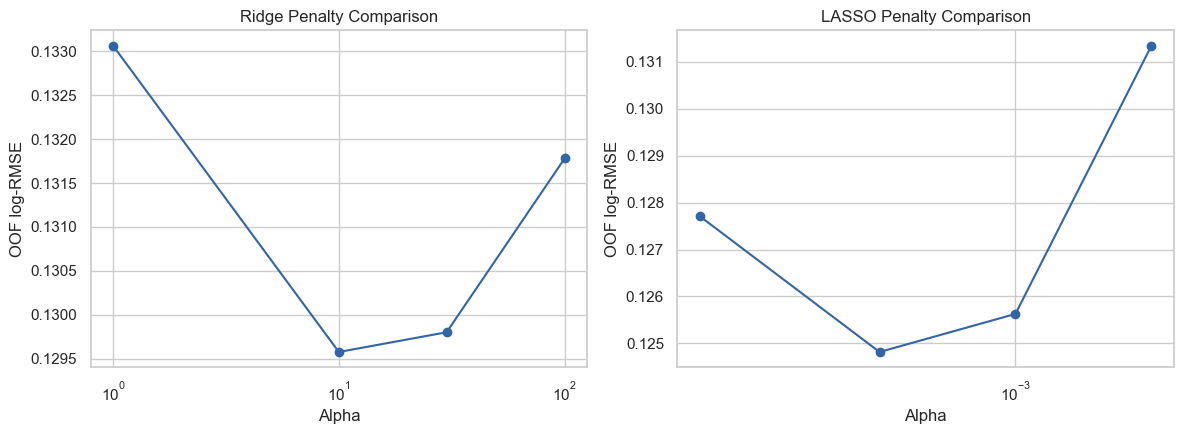

Selected Ridge alpha: 10.0
Selected LASSO alpha: 0.0005


,Model or policy,Full OOF log-RMSE,Core OOF log-RMSE,Extreme-case log-RMSE,Mean fold log-RMSE,Fold SD
0,Keep all training rows,0.12482,0.11160,1.07362,0.12293,0.02161
1,Exclude GrLivArea > 4000 from fitting,0.13214,0.11020,1.39753,0.12848,0.03089


,Fold,Full RMSE,Core RMSE,Extreme rows
0,1,0.11923,0.11698,1
1,2,0.15877,0.12316,1
2,3,0.11103,0.11103,0
3,4,0.13138,0.11057,2
4,5,0.09425,0.09425,0


,Id,GrLivArea,SalePrice,Keep-all prediction,Documented-rule prediction,Keep-all log residual,Documented-rule log residual,Fold
523,524,4676,184750,"616,549.34340","854,757.66416",-1.20513,-1.53181,4
691,692,4316,755000,"614,680.50945","722,257.38976",0.20561,0.04434,4
1182,1183,4476,745000,"493,940.44405","646,341.30517",0.41097,0.14206,1
1298,1299,5642,160000,"890,600.28226","1,649,720.66718",-1.71672,-2.33318,2


,LASSO feature set,Log RMSE,Log MSE,Log MAE,Log R²,Dollar RMSE,Dollar MSE,Dollar MAE,Dollar R²
0,Base engineered features,0.12482,0.01558,0.07867,0.90229,"31,733.10805","1,006,990,146.41135","14,457.92608",0.84033
1,Base features + six presence indicators,0.12482,0.01558,0.07868,0.90228,"31,736.92500","1,007,232,408.67116","14,460.42689",0.84029


Selected LASSO feature set: Base engineered features


,Model,Log RMSE,Log MSE,Log MAE,Log R²,Dollar RMSE,Dollar MSE,Dollar MAE,Dollar R²
0,LASSO,0.12482,0.01558,0.07867,0.90229,"31,733.10805","1,006,990,146.41135","14,457.92608",0.84033
1,Ridge,0.12958,0.01679,0.08198,0.89470,"33,461.45152","1,119,668,737.55097","15,144.25485",0.82247
2,Linear Regression baseline,0.21105,0.04454,0.09542,0.72065,"39,647.36980","1,571,913,932.39336","16,268.57099",0.75076


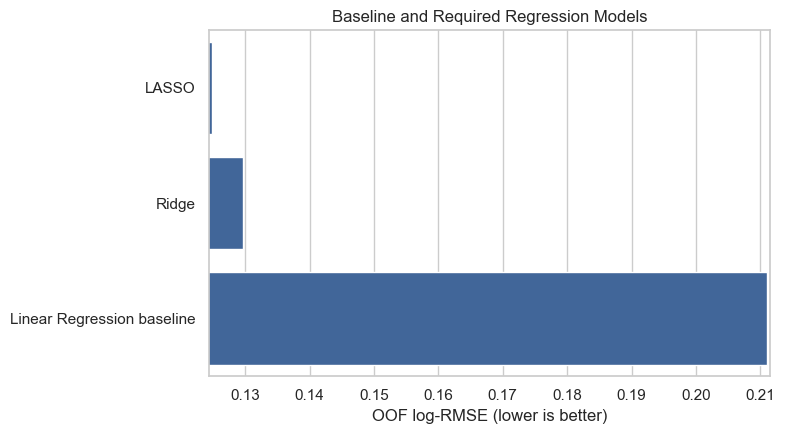

Selected outlier policy: Keep all training rows


In [12]:
start_time = time.time()

# Compare a small set of penalty values for the two required models.
ridge_alpha_rows = []
for alpha in [1, 10, 30, 100]:
    def make_ridge_trial(seed, alpha=alpha):
        return Ridge(alpha=alpha)

    trial_oof, _ = run_sklearn_cv(
        X_linear_base, X_linear_test_base, make_ridge_trial,
        cv_seed=CV_SEED, excluded_rows=None,
    )
    ridge_alpha_rows.append({
        "Model": "Ridge", "Alpha": alpha,
        "OOF log-RMSE": log_rmse(y_log, trial_oof),
    })

lasso_alpha_rows = []
for alpha in [0.0002, 0.0005, 0.001, 0.002]:
    def make_lasso_trial(seed, alpha=alpha):
        return Lasso(alpha=alpha, max_iter=50000)

    trial_oof, _ = run_sklearn_cv(
        X_linear_base, X_linear_test_base, make_lasso_trial,
        cv_seed=CV_SEED, excluded_rows=None,
    )
    lasso_alpha_rows.append({
        "Model": "LASSO", "Alpha": alpha,
        "OOF log-RMSE": log_rmse(y_log, trial_oof),
    })

penalty_results = pd.DataFrame(ridge_alpha_rows + lasso_alpha_rows)
display(penalty_results.sort_values(["Model", "OOF log-RMSE"]).reset_index(drop=True))

best_ridge_alpha = penalty_results.loc[
    penalty_results["Model"] == "Ridge"
].sort_values("OOF log-RMSE").iloc[0]["Alpha"]
best_lasso_alpha = penalty_results.loc[
    penalty_results["Model"] == "LASSO"
].sort_values("OOF log-RMSE").iloc[0]["Alpha"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for model_name, ax in zip(["Ridge", "LASSO"], axes):
    plot_data = penalty_results[penalty_results["Model"] == model_name]
    ax.plot(plot_data["Alpha"], plot_data["OOF log-RMSE"], marker="o", color=BLUE)
    ax.set_xscale("log")
    ax.set_title(f"{model_name} Penalty Comparison")
    ax.set_xlabel("Alpha")
    ax.set_ylabel("OOF log-RMSE")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_ridge_lasso_alpha.png", dpi=200, bbox_inches="tight")
plt.show()

def make_ridge(seed):
    return Ridge(alpha=best_ridge_alpha)

def make_lasso(seed):
    return Lasso(alpha=best_lasso_alpha, max_iter=50000)

print(f"Selected Ridge alpha: {best_ridge_alpha}")
print(f"Selected LASSO alpha: {best_lasso_alpha}")

# Outlier-policy experiment: change only the rows used to fit the model.
lasso_keep_oof, lasso_keep_test = run_sklearn_cv(
    X_linear_base, X_linear_test_base, make_lasso,
    cv_seed=CV_SEED, excluded_rows=None,
)
lasso_rule_oof, lasso_rule_test = run_sklearn_cv(
    X_linear_base, X_linear_test_base, make_lasso,
    cv_seed=CV_SEED, excluded_rows=extreme_mask,
)

outlier_policy_results = pd.DataFrame([
    validation_diagnostics("Keep all training rows", lasso_keep_oof),
    validation_diagnostics("Exclude GrLivArea > 4000 from fitting", lasso_rule_oof),
]).sort_values("Full OOF log-RMSE").reset_index(drop=True)
display(outlier_policy_results)

selected_outlier_policy = outlier_policy_results.iloc[0]["Model or policy"]
if selected_outlier_policy == "Exclude GrLivArea > 4000 from fitting":
    selected_excluded_rows = extreme_mask
    lasso_base_oof, lasso_base_test = lasso_rule_oof, lasso_rule_test
else:
    selected_excluded_rows = None
    lasso_base_oof, lasso_base_test = lasso_keep_oof, lasso_keep_test

policy_fold_results = fold_diagnostics(lasso_base_oof)
display(policy_fold_results)

extreme_case_results = train.loc[
    extreme_mask, ["Id", "GrLivArea", "SalePrice"]
].copy()
extreme_case_results["Keep-all prediction"] = np.expm1(
    lasso_keep_oof[extreme_mask.to_numpy()]
)
extreme_case_results["Documented-rule prediction"] = np.expm1(
    lasso_rule_oof[extreme_mask.to_numpy()]
)
extreme_case_results["Keep-all log residual"] = (
    y_log[extreme_mask.to_numpy()] - lasso_keep_oof[extreme_mask.to_numpy()]
)
extreme_case_results["Documented-rule log residual"] = (
    y_log[extreme_mask.to_numpy()] - lasso_rule_oof[extreme_mask.to_numpy()]
)
extreme_case_results["Fold"] = OOF_FOLD[extreme_mask.to_numpy()]
display(extreme_case_results)

# Use the selected outlier policy for the remaining model comparisons.
ridge_oof, ridge_test_prediction = run_sklearn_cv(
    X_linear_base, X_linear_test_base, make_ridge,
    cv_seed=CV_SEED, excluded_rows=selected_excluded_rows,
)

# Linear Regression is the unregularized baseline.
def make_linear_regression(seed):
    return LinearRegression()

baseline_oof, baseline_test_prediction = run_sklearn_cv(
    X_linear_base, X_linear_test_base, make_linear_regression,
    cv_seed=CV_SEED, excluded_rows=selected_excluded_rows,
)

lasso_eda_oof, lasso_eda_test = run_sklearn_cv(
    X_linear_eda, X_linear_test_eda, make_lasso,
    cv_seed=CV_SEED, excluded_rows=selected_excluded_rows,
)

lasso_feature_results = pd.DataFrame([
    {"LASSO feature set": "Base engineered features", **regression_metrics(y_log, lasso_base_oof)},
    {"LASSO feature set": "Base features + six presence indicators", **regression_metrics(y_log, lasso_eda_oof)},
]).sort_values("Log RMSE").reset_index(drop=True)
display(lasso_feature_results)

use_eda_indicators = (
    log_rmse(y_log, lasso_eda_oof) < log_rmse(y_log, lasso_base_oof)
)
if use_eda_indicators:
    lasso_oof_1, lasso_test_1 = lasso_eda_oof, lasso_eda_test
    X_linear, X_linear_test = X_linear_eda, X_linear_test_eda
    selected_lasso_features = "Base features + six presence indicators"
else:
    lasso_oof_1, lasso_test_1 = lasso_base_oof, lasso_base_test
    X_linear, X_linear_test = X_linear_base, X_linear_test_base
    selected_lasso_features = "Base engineered features"
print(f"Selected LASSO feature set: {selected_lasso_features}")

required_model_results = pd.DataFrame([
    {"Model": "Linear Regression baseline", **regression_metrics(y_log, baseline_oof)},
    {"Model": "Ridge", **regression_metrics(y_log, ridge_oof)},
    {"Model": "LASSO", **regression_metrics(y_log, lasso_oof_1)},
]).sort_values("Log RMSE").reset_index(drop=True)
display(required_model_results)

plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=required_model_results,
    x="Log RMSE", y="Model",
    color=BLUE,
)
required_min = required_model_results["Log RMSE"].min()
required_max = required_model_results["Log RMSE"].max()
plt.xlim(required_min - 0.0005, required_max + 0.0005)
plt.xlabel("OOF log-RMSE (lower is better)")
plt.title("Baseline and Required Regression Models")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_baseline_ridge_lasso.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Selected outlier policy: {selected_outlier_policy}")


**Outlier hypothesis.** Very large houses may follow a different price pattern. Two policies were tested with the same folds: keep every fitting row, or exclude houses above 4,000 square feet only from fitting. Every validation row remained in the Full OOF score. Core and extreme-case results explain where errors occur, but only Full OOF selects the policy.

**Required-model test.** Linear Regression provides a starting point without coefficient penalties. Four penalty values were compared for Ridge and four for LASSO. The best alpha for each required model was selected using the same OOF log-RMSE. A second table tests whether six simple presence indicators improve LASSO.

**Result and decision.** Keeping every fitting row produced the lower Full OOF error. Excluding all four large houses slightly improved Core RMSE but made the extreme-house errors much worse, so the documented exclusion rule was rejected. LASSO performed better than Ridge and remains the linear component.

## 9. Test other model directions


Random Forest validation completed
XGBoost validation completed


,Model direction,OOF log-RMSE,Decision
0,XGBoost,0.11897,Screened before final ensemble
1,LASSO,0.12482,Selected linear direction
2,Ridge,0.12958,Required comparison
3,Random Forest,0.13844,Screened before final ensemble
4,Linear Regression baseline,0.21105,Starting point


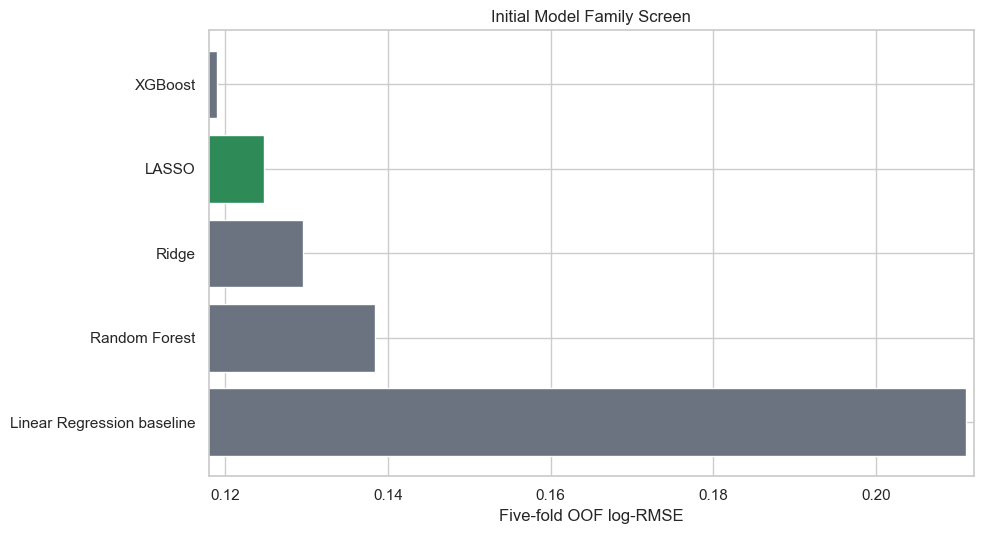

In [13]:
# Run one clear Random Forest and one XGBoost setting with the same data and folds.
def make_random_forest(seed):
    return RandomForestRegressor(
        n_estimators=700,
        max_features=0.70,
        min_samples_leaf=1,
        random_state=seed,
        n_jobs=-1,
    )

def make_xgboost(seed):
    return XGBRegressor(
        n_estimators=3000,
        learning_rate=0.02,
        max_depth=2,
        min_child_weight=1,
        subsample=0.75,
        colsample_bytree=0.70,
        reg_alpha=0.01,
        reg_lambda=1.0,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=seed,
        n_jobs=-1,
        verbosity=0,
    )

rf_oof, rf_test_prediction = run_sklearn_cv(
    X_tree, X_tree_test, make_random_forest,
    cv_seed=CV_SEED, excluded_rows=selected_excluded_rows,
)
print("Random Forest validation completed")

xgb_oof, xgb_test_prediction = run_sklearn_cv(
    X_tree, X_tree_test, make_xgboost,
    cv_seed=CV_SEED, excluded_rows=selected_excluded_rows,
)
print("XGBoost validation completed")

direction_predictions = {
    "Linear Regression baseline": baseline_oof,
    "Ridge": ridge_oof,
    "LASSO": lasso_oof_1,
    "Random Forest": rf_oof,
    "XGBoost": xgb_oof,
}
direction_results = pd.DataFrame([
    {
        "Model direction": name,
        "OOF log-RMSE": log_rmse(y_log, prediction),
        "Decision": (
            "Starting point" if name == "Linear Regression baseline"
            else "Required comparison" if name == "Ridge"
            else "Selected linear direction" if name == "LASSO"
            else "Screened before final ensemble"
        ),
    }
    for name, prediction in direction_predictions.items()
]).sort_values("OOF log-RMSE").reset_index(drop=True)
display(direction_results)

plot_direction = direction_results.sort_values("OOF log-RMSE", ascending=False)
plt.figure(figsize=(10, 5.5))
colors = [
    GREEN if name == "LASSO" else GREY
    for name in plot_direction["Model direction"]
]
plt.barh(plot_direction["Model direction"], plot_direction["OOF log-RMSE"], color=colors)
score_min = plot_direction["OOF log-RMSE"].min()
score_max = plot_direction["OOF log-RMSE"].max()
plt.xlim(score_min - 0.001, score_max + 0.001)
plt.xlabel("Five-fold OOF log-RMSE")
plt.ylabel("")
plt.title("Initial Model Family Screen")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_model_directions.png", dpi=200, bbox_inches="tight")
plt.show()


**Finding.** Random Forest and XGBoost use the same cleaned data, five folds and seed as Ridge and LASSO.

**Decision.** Keep their results in the full model comparison. They are not added to the main ensemble unless their OOF error and residual pattern support doing so. Test ElasticNet next for correlated predictors and SVR for smooth non-linear patterns.


### 9.1 Test ElasticNet and SVR


In [14]:
# ElasticNet combines the LASSO and Ridge penalty ideas.
elasticnet_rows = []
elasticnet_predictions = {}
for alpha in [0.0002, 0.0005, 0.0010]:
    for l1_ratio in [0.2, 0.5, 0.8]:
        def make_elasticnet(seed, alpha=alpha, l1_ratio=l1_ratio):
            return ElasticNet(
                alpha=alpha, l1_ratio=l1_ratio, max_iter=50000
            )

        enet_oof_try, enet_test_try = run_sklearn_cv(
            X_linear, X_linear_test, make_elasticnet,
            cv_seed=CV_SEED, excluded_rows=selected_excluded_rows,
        )
        name = f"alpha={alpha}, l1_ratio={l1_ratio}"
        elasticnet_predictions[name] = (enet_oof_try, enet_test_try)
        elasticnet_rows.append({
            "Setting": name,
            "Alpha": alpha,
            "L1 ratio": l1_ratio,
            **regression_metrics(y_log, enet_oof_try),
        })

elasticnet_results = pd.DataFrame(elasticnet_rows).sort_values("Log RMSE").reset_index(drop=True)
display(elasticnet_results[["Setting", "Log RMSE", "Log MAE", "Log R²"]])
best_enet_name = elasticnet_results.iloc[0]["Setting"]
enet_oof, enet_test_prediction = elasticnet_predictions[best_enet_name]

def make_svr(seed):
    return SVR(kernel="rbf", C=10, epsilon=0.01, gamma="scale")

svr_oof, svr_test_prediction = run_sklearn_cv(
    X_linear, X_linear_test, make_svr,
    cv_seed=CV_SEED, excluded_rows=selected_excluded_rows,
)

low_cost_model_results = pd.DataFrame([
    {"Model": "LASSO", **regression_metrics(y_log, lasso_oof_1)},
    {"Model": f"ElasticNet ({best_enet_name})", **regression_metrics(y_log, enet_oof)},
    {"Model": "RBF SVR", **regression_metrics(y_log, svr_oof)},
]).sort_values("Log RMSE").reset_index(drop=True)
display(low_cost_model_results)


,Setting,Log RMSE,Log MAE,Log R²
0,"alpha=0.0005, l1_ratio=0.8",0.12492,0.07870,0.90213
1,"alpha=0.001, l1_ratio=0.8",0.12503,0.07965,0.90197
2,"alpha=0.001, l1_ratio=0.5",0.12511,0.07938,0.90184
3,"alpha=0.0005, l1_ratio=0.5",0.12578,0.07926,0.90078
4,"alpha=0.001, l1_ratio=0.2",0.12663,0.08024,0.89944
5,"alpha=0.0002, l1_ratio=0.8",0.12821,0.07974,0.89691
6,"alpha=0.0005, l1_ratio=0.2",0.12901,0.08155,0.89561
7,"alpha=0.0002, l1_ratio=0.5",0.12980,0.08121,0.89434
8,"alpha=0.0002, l1_ratio=0.2",0.13299,0.08396,0.88907


,Model,Log RMSE,Log MSE,Log MAE,Log R²,Dollar RMSE,Dollar MSE,Dollar MAE,Dollar R²
0,LASSO,0.12482,0.01558,0.07867,0.90229,"31,733.10805","1,006,990,146.41135","14,457.92608",0.84033
1,"ElasticNet (alpha=0.0005, l1_ratio=0.8)",0.12492,0.01561,0.07870,0.90213,"31,714.68295","1,005,821,114.64907","14,467.45583",0.84052
2,RBF SVR,0.12975,0.01683,0.07865,0.89442,"34,926.70792","1,219,874,925.86490","14,439.52318",0.80658


**ElasticNet hypothesis.** Several engineered predictors describe similar ideas, such as living area, total area and quality-adjusted area. ElasticNet may keep correlated information more steadily than pure LASSO.

**SVR hypothesis.** House prices may change through smooth curves that are not captured by a linear model. One RBF SVR setting is tested first. A large parameter search is not used.

**Decision rule.** A new model can be useful if it has competitive Full OOF error or if its later residuals differ from the stronger models.

**Result and decision.** ElasticNet was very close to LASSO but did not improve Full OOF error. Their residual correlation was also almost 1, so ElasticNet added little new information. SVR had a weaker Full OOF score. A small SVR weight is still checked once in the ensemble because its residual pattern is less similar to CatBoost.


## 10. Validate the main model components


In [15]:
def make_gradient_boosting(seed):
    return GradientBoostingRegressor(
        n_estimators=2800,
        learning_rate=0.02,
        max_depth=3,
        min_samples_leaf=15,
        min_samples_split=10,
        max_features="sqrt",
        subsample=0.85,
        loss="huber",
        random_state=seed,
    )

def prepare_catboost_data(features):
    prepared = features.copy()
    category_columns = prepared.select_dtypes(include="object").columns.tolist()
    for column in category_columns:
        prepared[column] = prepared[column].fillna("Missing").astype(str)
    return prepared, category_columns

def run_catboost_cv(
    features, test_features, cv_seed, excluded_rows=None
):
    prepared, category_columns = prepare_catboost_data(features)
    prepared_test, _ = prepare_catboost_data(test_features)
    folds = KFold(n_splits=5, shuffle=True, random_state=cv_seed)
    oof_prediction = np.zeros(len(prepared))
    test_predictions = []

    for fold_number, (train_index, valid_index) in enumerate(
        folds.split(prepared), start=1
    ):
        fit_index = train_index
        if excluded_rows is not None:
            fit_index = train_index[~excluded_rows.iloc[train_index].to_numpy()]
        model = CatBoostRegressor(
            iterations=1400,
            learning_rate=0.025,
            depth=5,
            l2_leaf_reg=5,
            random_strength=0.5,
            loss_function="RMSE",
            # Stable sequential seeds for the five fitted fold models.
            random_seed=cv_seed + fold_number,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )
        model.fit(
            prepared.iloc[fit_index], y_log[fit_index],
            cat_features=category_columns,
        )
        oof_prediction[valid_index] = model.predict(prepared.iloc[valid_index])
        test_predictions.append(model.predict(prepared_test))

    return oof_prediction, np.mean(test_predictions, axis=0)

# LASSO was already validated in the required-model section.
lasso_oof = lasso_oof_1
lasso_test_prediction = lasso_test_1

gb_oof, gb_test_prediction = run_sklearn_cv(
    X_tree, X_tree_test, make_gradient_boosting, cv_seed=CV_SEED,
    excluded_rows=selected_excluded_rows,
)
print("Gradient Boosting validation completed")

cat_oof, cat_test_prediction = run_catboost_cv(
    X_tree, X_tree_test, cv_seed=CV_SEED,
    excluded_rows=selected_excluded_rows,
)
print("CatBoost validation completed")

component_predictions = {
    "Linear Regression baseline": baseline_oof,
    "Ridge": ridge_oof,
    "LASSO": lasso_oof,
    "ElasticNet": enet_oof,
    "RBF SVR": svr_oof,
    "Random Forest": rf_oof,
    "XGBoost": xgb_oof,
    "Gradient Boosting": gb_oof,
    "CatBoost": cat_oof,
}

def summarize_components(predictions):
    rows = []
    for name, prediction in predictions.items():
        mean_fold_score, fold_sd = fold_score_summary(y_log, prediction)
        rows.append({
            "Model": name,
            **regression_metrics(y_log, prediction),
            "Mean fold log-RMSE": mean_fold_score,
            "Fold SD": fold_sd,
        })
    return pd.DataFrame(rows).sort_values("Log RMSE").reset_index(drop=True)

component_results = summarize_components(component_predictions)
display(component_results[["Model", "Log MSE", "Log RMSE", "Log MAE", "Log R²", "Fold SD"]])


Gradient Boosting validation completed
CatBoost validation completed


,Model,Log MSE,Log RMSE,Log MAE,Log R²,Fold SD
0,XGBoost,0.01415,0.11897,0.07887,0.91123,0.00996
1,CatBoost,0.01445,0.12020,0.07873,0.90939,0.01135
2,Gradient Boosting,0.01508,0.12278,0.07717,0.90546,0.01773
3,LASSO,0.01558,0.12482,0.07867,0.90229,0.02161
4,ElasticNet,0.01561,0.12492,0.07870,0.90213,0.02169
5,Ridge,0.01679,0.12958,0.08198,0.89470,0.01990
6,RBF SVR,0.01683,0.12975,0.07865,0.89442,0.02519
7,Random Forest,0.01917,0.13844,0.09197,0.87980,0.01461
8,Linear Regression baseline,0.04454,0.21105,0.09542,0.72065,0.09392


**Why use the same folds.** Every model is tested on the same five validation groups. This makes the comparison direct. The fold standard deviation shows whether a result depends heavily on one part of the data.

**Initial result.** The table above compares all tested individual models. Section 10.2 then tests one small LASSO feature change. XGBoost has the lowest single-model OOF error at this stage, while Random Forest has the highest.

**Metric roles.** Log-RMSE is the main selection measure. Log-MSE gives the same ranking because RMSE is its square root. Log-MAE shows the typical absolute error, while Log R² shows how much variation the model explains. Dollar metrics are easier to explain but are not used for model selection.

### 10.1 Use residuals to choose a feature experiment


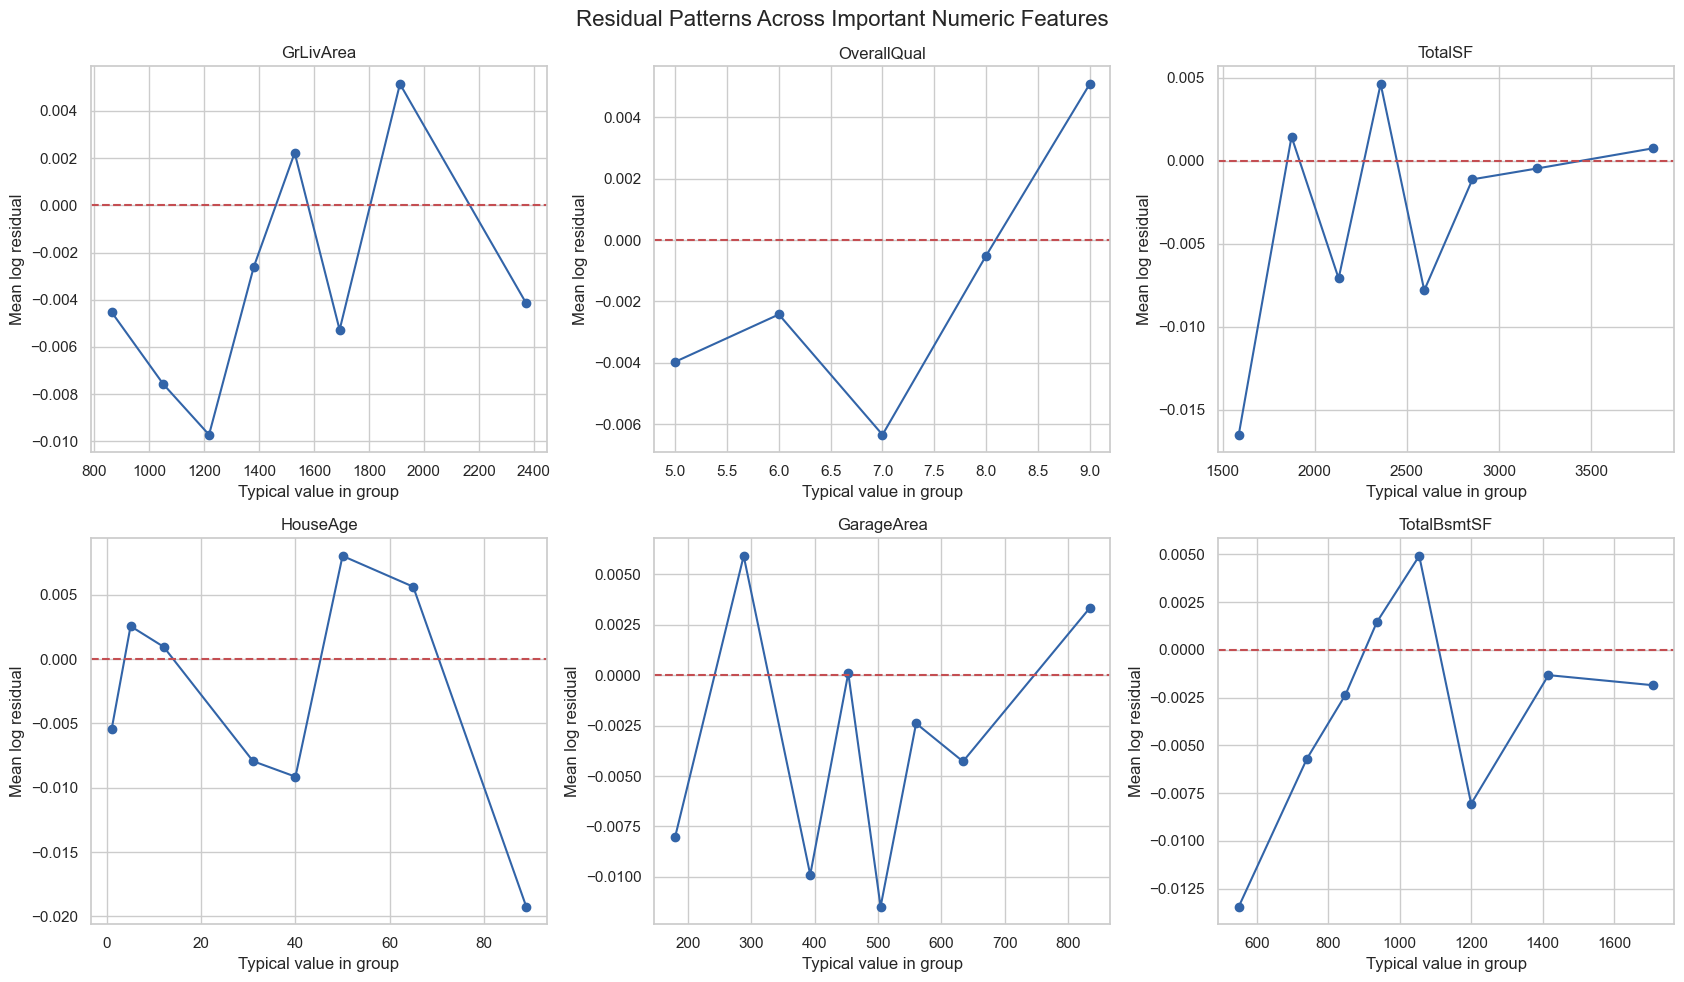

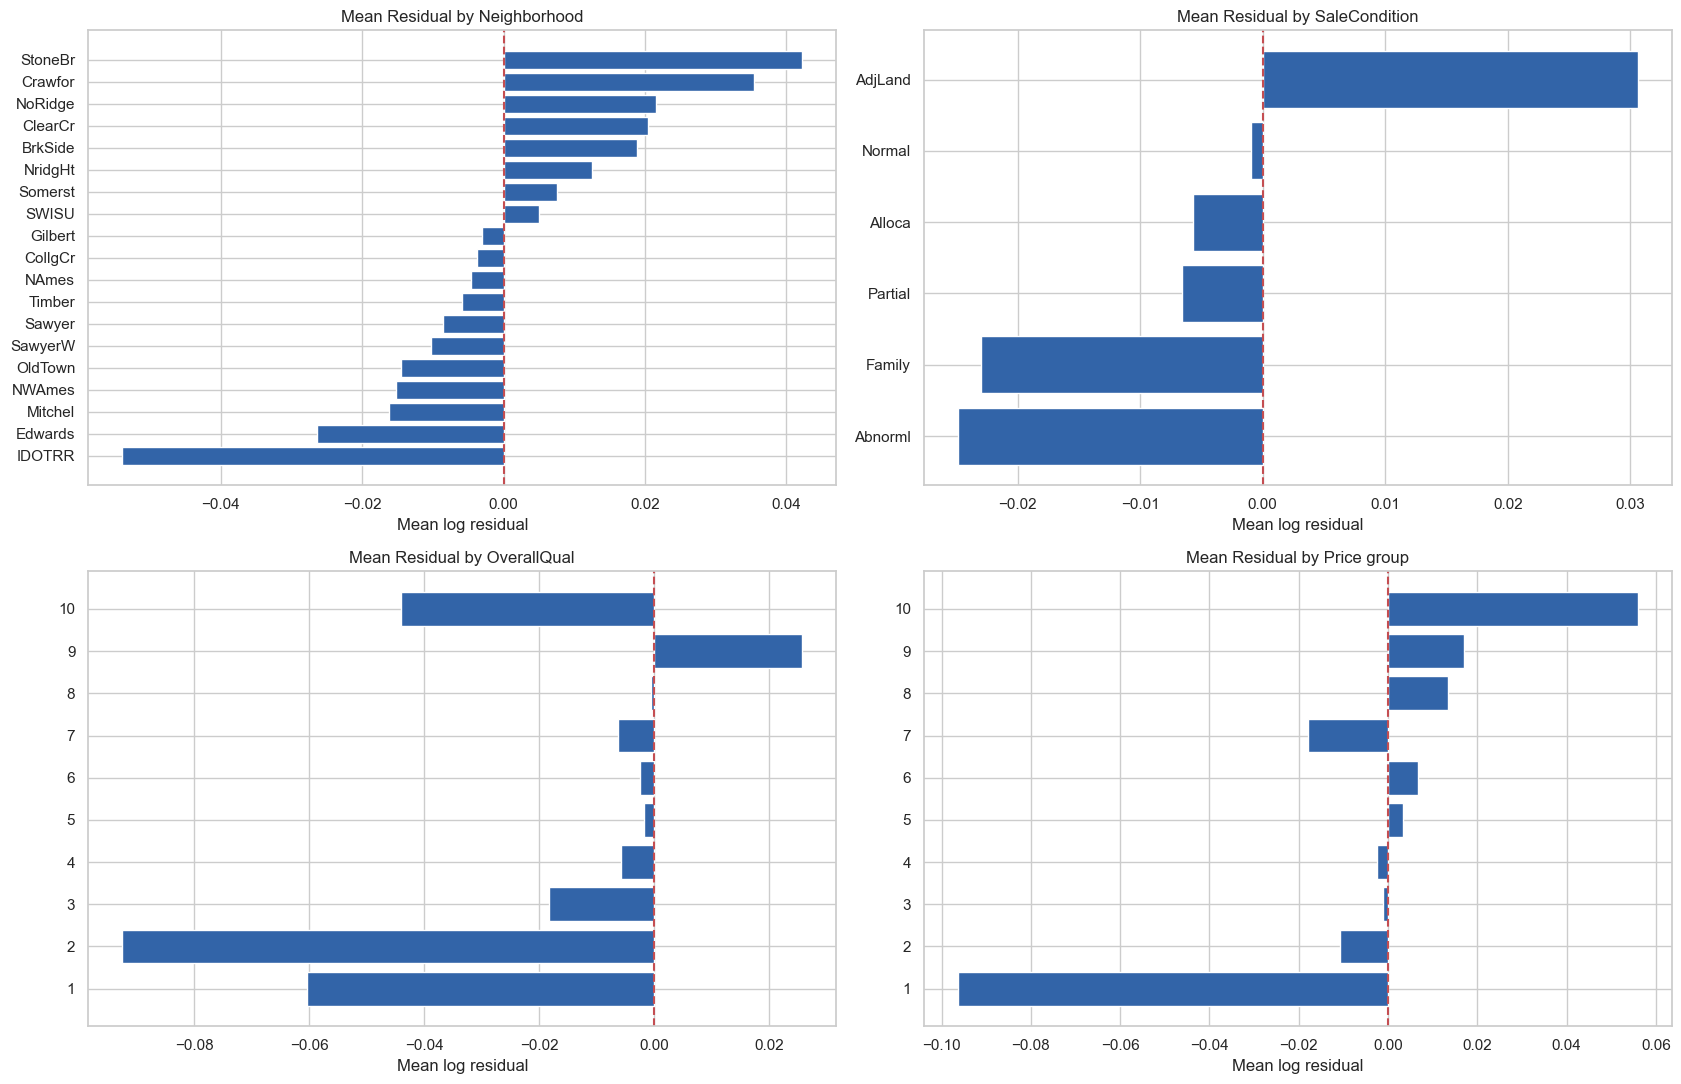

,mean,median,count
OverallQual,,,
1,-0.06034,-0.06034,2
2,-0.09249,0.00401,3
3,-0.01828,0.00874,20
4,-0.00585,0.01697,116
5,-0.00174,0.00720,397
6,-0.00243,0.00297,374
7,-0.00635,-0.00356,319
8,-0.00051,-0.00654,168
9,0.02568,0.01588,43


,mean,median,count
Price group,,,
1,-0.09632,-0.06776,146
2,-0.01074,0.00012,149
3,-0.00123,0.00429,144
4,-0.00251,0.00414,150
5,0.00338,0.00941,143
6,0.00676,0.00879,144
7,-0.01785,-0.01217,146
8,0.01334,0.01199,149
9,0.01692,0.01514,144


In [16]:
# Use a neutral three-model average before testing detailed ensemble weights.
preliminary_oof = (lasso_oof + gb_oof + cat_oof) / 3
preliminary_residual = y_log - preliminary_oof

residual_data = train[[
    "Id", "SalePrice", "GrLivArea", "OverallQual", "GarageArea",
    "TotalBsmtSF", "Neighborhood", "SaleCondition",
]].copy()
residual_data["TotalSF"] = (
    train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"]
)
residual_data["HouseAge"] = (
    train["YrSold"] - train["YearBuilt"]
).clip(lower=0)
residual_data["Residual"] = preliminary_residual
residual_data["Price group"] = pd.qcut(
    train["SalePrice"], 10, labels=False, duplicates="drop"
) + 1

numeric_residual_features = [
    "GrLivArea", "OverallQual", "TotalSF",
    "HouseAge", "GarageArea", "TotalBsmtSF",
]
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
numeric_residual_rows = []
for feature, ax in zip(numeric_residual_features, axes.flat):
    plot_data = residual_data[[feature, "Residual"]].dropna().copy()
    plot_data["Group"] = pd.qcut(
        plot_data[feature], 8, duplicates="drop"
    )
    grouped = plot_data.groupby("Group", observed=True).agg(
        Feature_value=(feature, "median"),
        Mean_residual=("Residual", "mean"),
        Houses=("Residual", "size"),
    )
    ax.plot(
        grouped["Feature_value"], grouped["Mean_residual"],
        marker="o", color=BLUE,
    )
    ax.axhline(0, linestyle="--", color=RED)
    ax.set_title(feature)
    ax.set_xlabel("Typical value in group")
    ax.set_ylabel("Mean log residual")
    for _, row in grouped.iterrows():
        numeric_residual_rows.append({
            "Feature": feature,
            "Feature value": row["Feature_value"],
            "Mean residual": row["Mean_residual"],
            "Houses": row["Houses"],
        })
plt.suptitle("Residual Patterns Across Important Numeric Features", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "09_numeric_residual_patterns.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
group_plots = [
    ("Neighborhood", 20),
    ("SaleCondition", 1),
    ("OverallQual", 1),
    ("Price group", 1),
]
group_residual_tables = {}
for (feature, minimum_count), ax in zip(group_plots, axes.flat):
    grouped = residual_data.groupby(feature)["Residual"].agg(
        ["mean", "median", "count"]
    )
    grouped = grouped[grouped["count"] >= minimum_count]
    if feature in ["OverallQual", "Price group"]:
        grouped = grouped.sort_index()
    else:
        grouped = grouped.sort_values("mean")
    group_residual_tables[feature] = grouped
    ax.barh(grouped.index.astype(str), grouped["mean"], color=BLUE)
    ax.axvline(0, linestyle="--", color=RED)
    ax.set_title(f"Mean Residual by {feature}")
    ax.set_xlabel("Mean log residual")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "10_group_residual_patterns.png", dpi=200, bbox_inches="tight")
plt.show()

display(group_residual_tables["OverallQual"])
display(group_residual_tables["Price group"])


**Finding.** The preliminary residual plots show some remaining curvature across house quality, age and price levels. The model tends to overpredict part of the lowest-price group and underpredict part of the highest-price group. Price groups are used only to diagnose bias; they are not model inputs because test-set prices are unknown.

**Hypothesis.** Curved quality and age effects may help the linear model at the low and high ends. Basement and garage value may also depend on both size and quality. The next experiment adds only these four terms.


### 10.2 Test targeted features


In [17]:
X_linear_targeted = clean_and_engineer(
    train.drop(columns="SalePrice"),
    use_ordinal_numbers=False,
    add_zero_indicators=use_eda_indicators,
    add_targeted_features=True,
)
X_linear_test_targeted = clean_and_engineer(
    test,
    use_ordinal_numbers=False,
    add_zero_indicators=use_eda_indicators,
    add_targeted_features=True,
)

targeted_lasso_oof, targeted_lasso_test = run_sklearn_cv(
    X_linear_targeted, X_linear_test_targeted, make_lasso,
    cv_seed=CV_SEED, excluded_rows=selected_excluded_rows,
)
targeted_feature_results = pd.DataFrame([
    {"Feature set": "Selected features before residual review", **regression_metrics(y_log, lasso_oof)},
    {"Feature set": "Add four residual-based features", **regression_metrics(y_log, targeted_lasso_oof)},
]).sort_values("Log RMSE").reset_index(drop=True)
display(targeted_feature_results)

use_targeted_features = (
    log_rmse(y_log, targeted_lasso_oof) < log_rmse(y_log, lasso_oof)
)
if use_targeted_features:
    X_linear = X_linear_targeted
    X_linear_test = X_linear_test_targeted
    lasso_oof = targeted_lasso_oof
    lasso_test_prediction = targeted_lasso_test
    selected_lasso_features += " + residual-based features"

component_predictions["LASSO"] = lasso_oof
component_results = summarize_components(component_predictions)

print("Final individual-model comparison after the LASSO feature test")
display(component_results[[
    "Model", "Log MSE", "Log RMSE", "Log MAE", "Log R²", "Fold SD"
]])

feature_decision = "Keep" if use_targeted_features else "Reject"
print(f"Targeted feature decision: {feature_decision}")


,Feature set,Log RMSE,Log MSE,Log MAE,Log R²,Dollar RMSE,Dollar MSE,Dollar MAE,Dollar R²
0,Add four residual-based features,0.12465,0.01554,0.07839,0.90256,"32,038.83570","1,026,486,993.06133","14,428.98439",0.83724
1,Selected features before residual review,0.12482,0.01558,0.07867,0.90229,"31,733.10805","1,006,990,146.41135","14,457.92608",0.84033


Final individual-model comparison after the LASSO feature test


,Model,Log MSE,Log RMSE,Log MAE,Log R²,Fold SD
0,XGBoost,0.01415,0.11897,0.07887,0.91123,0.00996
1,CatBoost,0.01445,0.12020,0.07873,0.90939,0.01135
2,Gradient Boosting,0.01508,0.12278,0.07717,0.90546,0.01773
3,LASSO,0.01554,0.12465,0.07839,0.90256,0.02175
4,ElasticNet,0.01561,0.12492,0.07870,0.90213,0.02169
5,Ridge,0.01679,0.12958,0.08198,0.89470,0.01990
6,RBF SVR,0.01683,0.12975,0.07865,0.89442,0.02519
7,Random Forest,0.01917,0.13844,0.09197,0.87980,0.01461
8,Linear Regression baseline,0.04454,0.21105,0.09542,0.72065,0.09392


Targeted feature decision: Keep


**Result and decision.** Adding squared quality, squared house age, basement value and garage value reduced the LASSO Full OOF log-RMSE from about 0.12482 to 0.12465. The improvement is small but comes from the same folds with no other change, so the four-feature group is kept.

The second table above is the final individual-model comparison. It replaces the earlier preliminary table when later ensemble decisions are made.

### 10.3 Compare residual patterns between models


,LASSO,ElasticNet,RBF SVR,XGBoost,Gradient Boosting,CatBoost
LASSO,1.00000,0.99781,0.92967,0.83374,0.87109,0.84068
ElasticNet,0.99781,1.00000,0.92341,0.83251,0.86502,0.83436
RBF SVR,0.92967,0.92341,1.00000,0.80361,0.89414,0.85410
XGBoost,0.83374,0.83251,0.80361,1.00000,0.90581,0.92400
Gradient Boosting,0.87109,0.86502,0.89414,0.90581,1.00000,0.92079
CatBoost,0.84068,0.83436,0.85410,0.92400,0.92079,1.00000


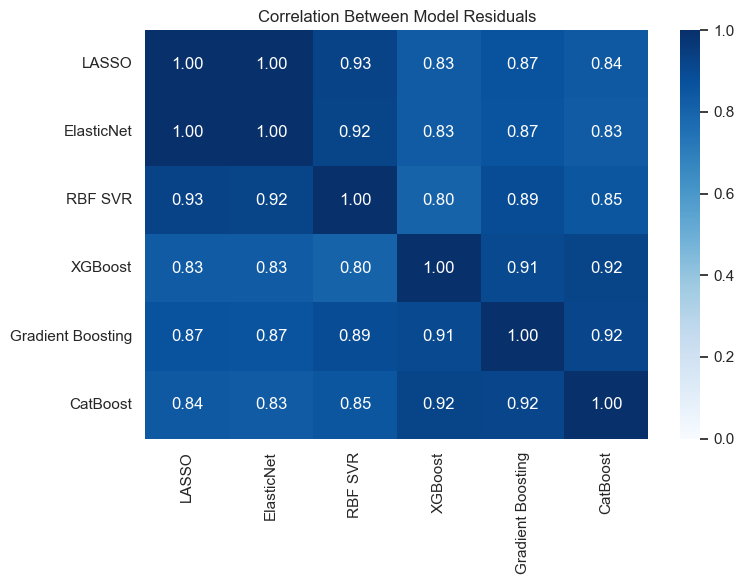

,Model or policy,Full OOF log-RMSE,Core OOF log-RMSE,Extreme-case log-RMSE,Mean fold log-RMSE,Fold SD
0,XGBoost,0.11897,0.11464,0.61891,0.11856,0.00996
1,CatBoost,0.12020,0.11557,0.64171,0.11966,0.01135
2,Gradient Boosting,0.12278,0.11279,0.93358,0.12149,0.01773
3,LASSO,0.12465,0.11115,1.08360,0.12273,0.02175
4,ElasticNet,0.12492,0.11175,1.07238,0.12302,0.02169
5,Ridge,0.12958,0.11596,1.11084,0.12804,0.01990
6,RBF SVR,0.12975,0.11447,1.17277,0.12728,0.02519
7,Random Forest,0.13844,0.13242,0.78269,0.13767,0.01461
8,Linear Regression baseline,0.21105,0.20195,1.18831,0.18900,0.09392


In [18]:
residual_model_names = [
    "LASSO", "ElasticNet", "RBF SVR", "XGBoost",
    "Gradient Boosting", "CatBoost",
]
model_residuals = pd.DataFrame({
    name: y_log - component_predictions[name]
    for name in residual_model_names
})
residual_correlation = model_residuals.corr()
display(residual_correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(
    residual_correlation, annot=True, fmt=".2f",
    cmap="Blues", vmin=0, vmax=1,
)
plt.title("Correlation Between Model Residuals")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "11_residual_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

component_diagnostics = pd.DataFrame([
    validation_diagnostics(name, prediction)
    for name, prediction in component_predictions.items()
]).sort_values("Full OOF log-RMSE").reset_index(drop=True)
display(component_diagnostics)

**How to read the matrix.** A value near 1 means two models tend to make similar errors on the same houses. ElasticNet and LASSO are almost identical, so keeping both would add little diversity. LASSO has lower residual correlation with the boosting models, which supports combining linear and tree-based predictions.

The residual matrix focuses on models that could reasonably enter an ensemble. Linear Regression and Ridge are already represented by the stronger LASSO direction. Random Forest is not included because its individual OOF error is much higher. All three models remain in the complete individual-model results table.

## 11. Compare clear ensemble weight choices


,Strategy,LASSO weight,Gradient Boosting weight,CatBoost weight,XGBoost weight,SVR weight,Log MSE,Log RMSE,Log MAE,Log R²
0,30% LASSO + 40% CatBoost + 30% XGBoost,0.30000,0.00000,0.40000,0.30000,0.00000,0.01340,0.11575,0.07472,0.91597
1,20% LASSO + 20% Gradient Boosting + 30% CatBoo...,0.20000,0.20000,0.30000,0.30000,0.00000,0.01345,0.11598,0.07438,0.91564
2,25% LASSO + 25% Gradient Boosting + 25% CatBoo...,0.25000,0.25000,0.25000,0.25000,0.00000,0.01349,0.11613,0.07395,0.91543
3,30% LASSO + 30% Gradient Boosting + 40% CatBoost,0.30000,0.30000,0.40000,0.00000,0.00000,0.01375,0.11726,0.07379,0.91377
4,33% LASSO + 33% Gradient Boosting + 33% CatBoost,0.33333,0.33333,0.33333,0.00000,0.00000,0.01379,0.11742,0.07364,0.91354
5,25% LASSO + 25% Gradient Boosting + 40% CatBoo...,0.25000,0.25000,0.40000,0.00000,0.10000,0.01382,0.11757,0.07360,0.91331
6,30% LASSO + 30% Gradient Boosting + 30% CatBoo...,0.30000,0.30000,0.30000,0.00000,0.10000,0.01389,0.11785,0.07343,0.91290
7,40% LASSO + 40% Gradient Boosting + 20% CatBoost,0.40000,0.40000,0.20000,0.00000,0.00000,0.01393,0.11802,0.07361,0.91264
8,50% Gradient Boosting + 50% CatBoost,0.00000,0.50000,0.50000,0.00000,0.00000,0.01418,0.11906,0.07567,0.91110


,Model,Log MSE,Log RMSE,Log MAE,Log R²,Fold SD
0,Leading internal candidate: 30% LASSO + 40% Ca...,0.01340,0.11575,0.07472,0.91597,0.01246
1,XGBoost,0.01415,0.11897,0.07887,0.91123,0.00996
2,CatBoost,0.01445,0.12020,0.07873,0.90939,0.01135
3,Gradient Boosting,0.01508,0.12278,0.07717,0.90546,0.01773
4,LASSO,0.01554,0.12465,0.07839,0.90256,0.02175
5,ElasticNet,0.01561,0.12492,0.07870,0.90213,0.02169
6,Ridge,0.01679,0.12958,0.08198,0.89470,0.01990
7,RBF SVR,0.01683,0.12975,0.07865,0.89442,0.02519
8,Random Forest,0.01917,0.13844,0.09197,0.87980,0.01461
9,Linear Regression baseline,0.04454,0.21105,0.09542,0.72065,0.09392


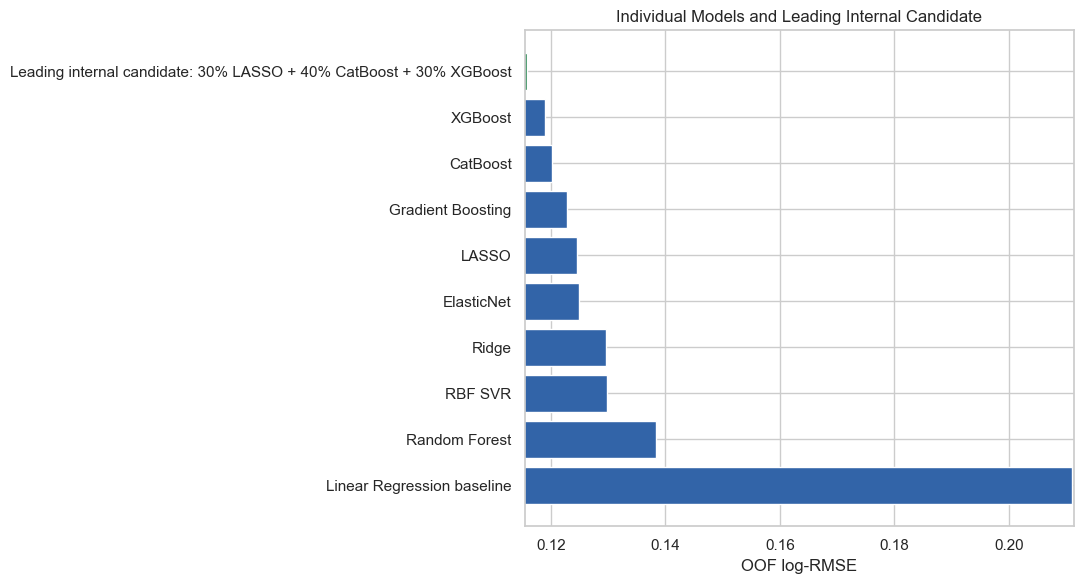

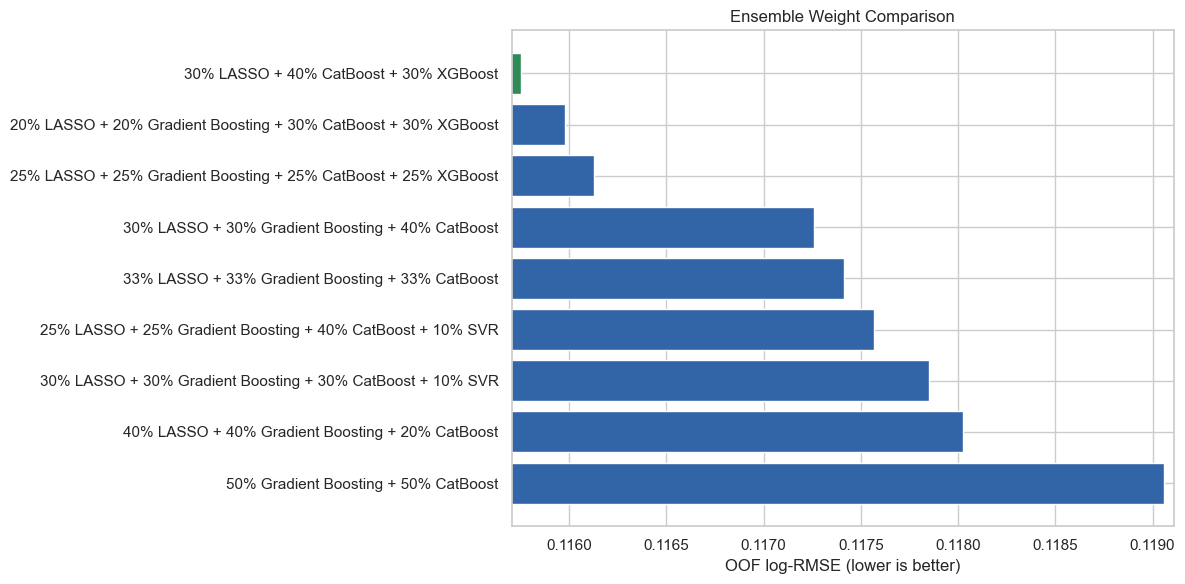

Leading internal candidate: 30% LASSO + 40% CatBoost + 30% XGBoost


In [19]:
# Each row is: LASSO, Gradient Boosting, CatBoost, XGBoost, SVR.
ensemble_weights = {
    "33% LASSO + 33% Gradient Boosting + 33% CatBoost": (1/3, 1/3, 1/3, 0.00, 0.00),
    "40% LASSO + 40% Gradient Boosting + 20% CatBoost": (0.40, 0.40, 0.20, 0.00, 0.00),
    "30% LASSO + 30% Gradient Boosting + 40% CatBoost": (0.30, 0.30, 0.40, 0.00, 0.00),
    "50% Gradient Boosting + 50% CatBoost": (0.00, 0.50, 0.50, 0.00, 0.00),
    "30% LASSO + 30% Gradient Boosting + 30% CatBoost + 10% SVR": (0.30, 0.30, 0.30, 0.00, 0.10),
    "25% LASSO + 25% Gradient Boosting + 40% CatBoost + 10% SVR": (0.25, 0.25, 0.40, 0.00, 0.10),
    "25% LASSO + 25% Gradient Boosting + 25% CatBoost + 25% XGBoost": (0.25, 0.25, 0.25, 0.25, 0.00),
    "20% LASSO + 20% Gradient Boosting + 30% CatBoost + 30% XGBoost": (0.20, 0.20, 0.30, 0.30, 0.00),
    "30% LASSO + 40% CatBoost + 30% XGBoost": (0.30, 0.00, 0.40, 0.30, 0.00),
}

ensemble_oof_predictions = {}
ensemble_test_predictions = {}
ensemble_rows = []

for name, weights in ensemble_weights.items():
    lasso_weight, gb_weight, cat_weight, xgb_weight, svr_weight = weights
    averaged_oof = (
        lasso_weight * lasso_oof
        + gb_weight * gb_oof
        + cat_weight * cat_oof
        + xgb_weight * xgb_oof
        + svr_weight * svr_oof
    )
    averaged_test = (
        lasso_weight * lasso_test_prediction
        + gb_weight * gb_test_prediction
        + cat_weight * cat_test_prediction
        + xgb_weight * xgb_test_prediction
        + svr_weight * svr_test_prediction
    )

    mean_fold_score, fold_sd = fold_score_summary(y_log, averaged_oof)
    ensemble_oof_predictions[name] = averaged_oof
    ensemble_test_predictions[name] = averaged_test
    ensemble_rows.append({
        "Strategy": name,
        "LASSO weight": lasso_weight,
        "Gradient Boosting weight": gb_weight,
        "CatBoost weight": cat_weight,
        "XGBoost weight": xgb_weight,
        "SVR weight": svr_weight,
        **regression_metrics(y_log, averaged_oof),
        "Mean fold log-RMSE": mean_fold_score,
        "Fold SD": fold_sd,
    })

ensemble_results = pd.DataFrame(ensemble_rows).sort_values("Log RMSE").reset_index(drop=True)
display(ensemble_results[[
    "Strategy", "LASSO weight", "Gradient Boosting weight",
    "CatBoost weight", "XGBoost weight", "SVR weight",
    "Log MSE", "Log RMSE", "Log MAE", "Log R²"
]])

# The lowest internal OOF result becomes the leading internal candidate.
internal_candidate_name = ensemble_results.iloc[0]["Strategy"]
internal_candidate_oof = ensemble_oof_predictions[internal_candidate_name]
internal_candidate_test_log = ensemble_test_predictions[internal_candidate_name]
internal_mean_fold_score, internal_fold_sd = fold_score_summary(
    y_log, internal_candidate_oof
)

internal_results = pd.concat([
    component_results,
    pd.DataFrame([{
        "Model": f"Leading internal candidate: {internal_candidate_name}",
        **regression_metrics(y_log, internal_candidate_oof),
        "Mean fold log-RMSE": internal_mean_fold_score,
        "Fold SD": internal_fold_sd,
    }]),
], ignore_index=True).sort_values("Log RMSE").reset_index(drop=True)
display(internal_results[["Model", "Log MSE", "Log RMSE", "Log MAE", "Log R²", "Fold SD"]])

plt.figure(figsize=(11, 6))
plot_internal = internal_results.sort_values("Log RMSE", ascending=False)
colors = [
    GREEN if name.startswith("Leading internal candidate") else BLUE
    for name in plot_internal["Model"]
]
plt.barh(plot_internal["Model"], plot_internal["Log RMSE"], color=colors)
internal_min = plot_internal["Log RMSE"].min()
internal_max = plot_internal["Log RMSE"].max()
plt.xlim(internal_min - 0.0003, internal_max + 0.0003)
plt.xlabel("OOF log-RMSE")
plt.ylabel("")
plt.title("Individual Models and Leading Internal Candidate")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "12_internal_model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 6))
plot_weights = ensemble_results.sort_values("Log RMSE", ascending=False)
colors = [GREEN if name == internal_candidate_name else BLUE for name in plot_weights["Strategy"]]
plt.barh(plot_weights["Strategy"], plot_weights["Log RMSE"], color=colors)
score_min = plot_weights["Log RMSE"].min()
score_max = plot_weights["Log RMSE"].max()
plt.xlim(score_min - 0.00005, score_max + 0.00005)
plt.xlabel("OOF log-RMSE (lower is better)")
plt.ylabel("")
plt.title("Ensemble Weight Comparison")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "13_ensemble_weight_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Leading internal candidate: {internal_candidate_name}")
ensemble_results.to_csv(OUTPUT_DIR / "ensemble_weight_comparison.csv", index=False)

**Why compare these weights.** The selected combinations test equal weights, different balances between linear and tree models, a small SVR contribution and the addition of XGBoost.

| Test | Purpose |
|---|---|
| 33% LASSO + 33% Gradient Boosting + 33% CatBoost | Neutral three-model starting point |
| 40% LASSO + 40% Gradient Boosting + 20% CatBoost | More weight on the linear and standard boosting models |
| 30% LASSO + 30% Gradient Boosting + 40% CatBoost | More weight on CatBoost |
| 50% Gradient Boosting + 50% CatBoost | Tree-model-only comparison |
| Two combinations with 10% SVR | Test whether a small amount of different SVR error helps |
| Two four-model combinations | Test whether XGBoost adds value to the core models |
| 30% LASSO + 40% CatBoost + 30% XGBoost | Test the three strongest or most useful non-redundant directions |

**Decision rule.** The lowest Full OOF log-RMSE identifies the leading candidate. Section 13 also retains every strategy below 0.120 for comparison. Small differences should be interpreted cautiously because the same OOF predictions are used to compare several weight choices.

## 12. Evaluate prediction quality


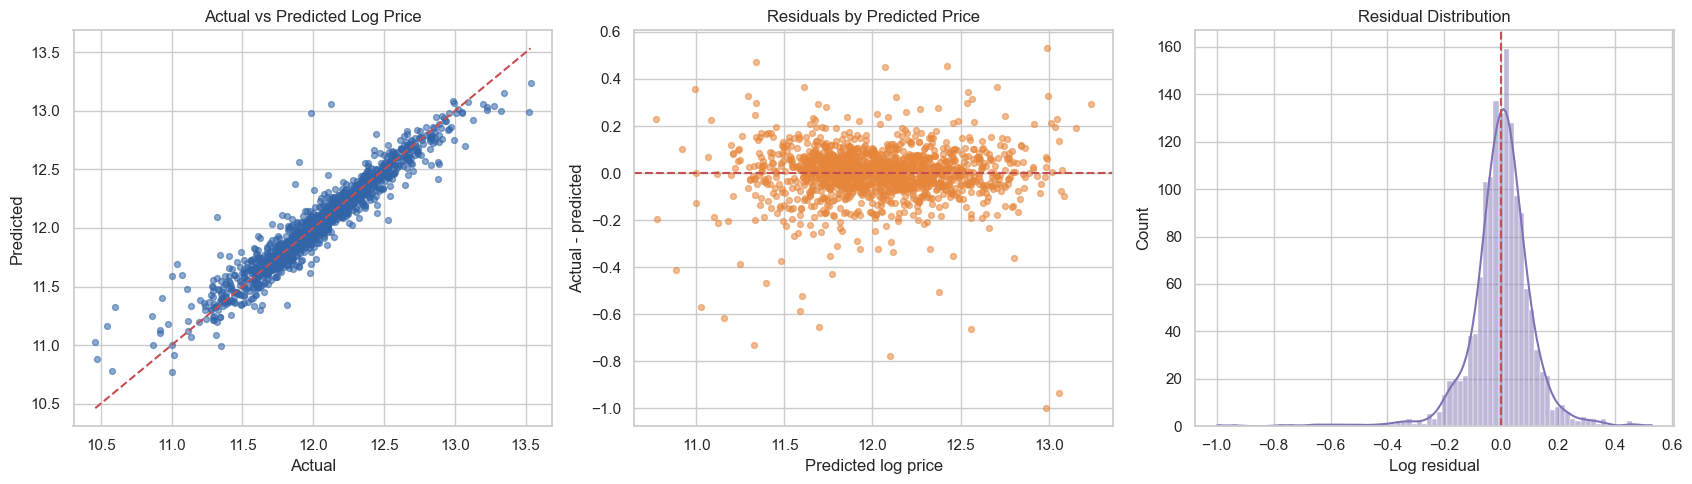

,Id,Actual SalePrice,Predicted log price,Residual,Absolute residual,"Home above 4,000 sq ft"
1298,1299,160000,12.98173,-0.99880,0.99880,True
523,524,184750,13.06021,-0.93344,0.93344,True
632,633,82500,12.09727,-0.77671,0.77671,False
30,31,40000,11.32890,-0.73224,0.73224,False
1324,1325,147000,12.56075,-0.66256,0.66256,False
462,463,62383,11.69433,-0.65326,0.65326,False
968,969,37900,11.15862,-0.61589,0.61589,False
410,411,60000,11.58623,-0.58411,0.58411,False
495,496,34900,11.02716,-0.56689,0.56689,False
1182,1183,745000,12.99116,0.52998,0.52998,True


In [20]:
residuals = y_log - internal_candidate_oof
residual_review = pd.DataFrame({
    "Id": train["Id"],
    "Actual SalePrice": train["SalePrice"],
    "Predicted log price": internal_candidate_oof,
    "Residual": residuals,
    "Absolute residual": np.abs(residuals),
    "Home above 4,000 sq ft": extreme_mask,
})

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].scatter(y_log, internal_candidate_oof, alpha=0.55, s=18, color=BLUE)
low = min(y_log.min(), internal_candidate_oof.min())
high = max(y_log.max(), internal_candidate_oof.max())
axes[0].plot([low, high], [low, high], "--", color=RED)
axes[0].set_title("Actual vs Predicted Log Price")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

axes[1].scatter(internal_candidate_oof, residuals, alpha=0.55, s=18, color=ORANGE)
axes[1].axhline(0, linestyle="--", color=RED)
axes[1].set_title("Residuals by Predicted Price")
axes[1].set_xlabel("Predicted log price")
axes[1].set_ylabel("Actual - predicted")

sns.histplot(residuals, kde=True, color=PURPLE, ax=axes[2])
axes[2].axvline(0, linestyle="--", color=RED)
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Log residual")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "14_residual_review.png", dpi=200, bbox_inches="tight")
plt.show()

display(residual_review.nlargest(10, "Absolute residual"))


**Evaluation.** Most predictions are close to the diagonal line, and residuals are centered near zero. Two of the four houses above 4,000 square feet remain the largest errors. This means the model is accurate for most homes but less reliable for rare properties that have few similar training examples.


## 13. Select and create candidate prediction files

Every file below comes from a model or ensemble already tested with the same five OOF folds.

The results are divided into three groups:

- **Leading candidate:** the single lowest OOF Log-RMSE.
- **Candidate shortlist:** every strategy with OOF Log-RMSE below 0.120.
- **Supporting output:** a tested direction that did not meet the shortlist rule.

The 0.120 cutoff keeps several strong approaches with different model structures for final comparison.

In [21]:
candidate_predictions = {
    "Linear Regression baseline": baseline_test_prediction,
    "Ridge": ridge_test_prediction,
    "LASSO": lasso_test_prediction,
    "ElasticNet": enet_test_prediction,
    "RBF SVR": svr_test_prediction,
    "Random Forest": rf_test_prediction,
    "XGBoost": xgb_test_prediction,
    "Gradient Boosting": gb_test_prediction,
    "CatBoost": cat_test_prediction,
}
candidate_predictions.update(ensemble_test_predictions)

candidate_oof_predictions = {
    "Linear Regression baseline": baseline_oof,
    "Ridge": ridge_oof,
    "LASSO": lasso_oof,
    "ElasticNet": enet_oof,
    "RBF SVR": svr_oof,
    "Random Forest": rf_oof,
    "XGBoost": xgb_oof,
    "Gradient Boosting": gb_oof,
    "CatBoost": cat_oof,
}
candidate_oof_predictions.update(ensemble_oof_predictions)

candidate_files = {
    "Linear Regression baseline": "submission_linear_regression.csv",
    "Ridge": "submission_ridge.csv",
    "LASSO": "submission_lasso.csv",
    "ElasticNet": "submission_elasticnet.csv",
    "RBF SVR": "submission_svr.csv",
    "Random Forest": "submission_random_forest.csv",
    "XGBoost": "submission_xgboost.csv",
    "Gradient Boosting": "submission_gradient_boosting.csv",
    "CatBoost": "submission_catboost.csv",
    "33% LASSO + 33% Gradient Boosting + 33% CatBoost": "submission_lasso33_gb33_catboost33.csv",
    "40% LASSO + 40% Gradient Boosting + 20% CatBoost": "submission_lasso40_gb40_catboost20.csv",
    "30% LASSO + 30% Gradient Boosting + 40% CatBoost": "submission_lasso30_gb30_catboost40.csv",
    "50% Gradient Boosting + 50% CatBoost": "submission_gb50_catboost50.csv",
    "30% LASSO + 30% Gradient Boosting + 30% CatBoost + 10% SVR": "submission_lasso30_gb30_catboost30_svr10.csv",
    "25% LASSO + 25% Gradient Boosting + 40% CatBoost + 10% SVR": "submission_lasso25_gb25_catboost40_svr10.csv",
    "25% LASSO + 25% Gradient Boosting + 25% CatBoost + 25% XGBoost": "submission_lasso25_gb25_catboost25_xgboost25.csv",
    "20% LASSO + 20% Gradient Boosting + 30% CatBoost + 30% XGBoost": "submission_lasso20_gb20_catboost30_xgboost30.csv",
    "30% LASSO + 40% CatBoost + 30% XGBoost": "submission_lasso30_catboost40_xgboost30.csv",
}

SHORTLIST_LIMIT = 0.120
individual_names = {
    "Linear Regression baseline", "Ridge", "LASSO", "ElasticNet",
    "RBF SVR", "Random Forest", "XGBoost", "Gradient Boosting", "CatBoost",
}
candidate_rows = []
candidate_metric_rows = []

for strategy, predicted_log_price in candidate_predictions.items():
    candidate_submission = pd.DataFrame({
        "Id": test["Id"],
        "SalePrice": np.expm1(predicted_log_price).clip(min=1),
    })
    output_path = SUBMISSION_DIR / candidate_files[strategy]
    candidate_submission.to_csv(output_path, index=False)

    valid_file = (
        len(candidate_submission) == len(test)
        and candidate_submission.columns.tolist() == ["Id", "SalePrice"]
        and candidate_submission["Id"].equals(test["Id"])
        and candidate_submission["SalePrice"].notna().all()
        and np.isfinite(candidate_submission["SalePrice"]).all()
        and (candidate_submission["SalePrice"] > 0).all()
    )

    metrics = regression_metrics(y_log, candidate_oof_predictions[strategy])
    if strategy == internal_candidate_name:
        role = "Leading internal candidate; external-test shortlist"
    elif metrics["Log RMSE"] < SHORTLIST_LIMIT:
        role = "External-test shortlist"
    else:
        role = "Supporting model output"

    candidate_metric_rows.append({"Strategy": strategy, **metrics})
    candidate_rows.append({
        "Strategy": strategy,
        "Model group": "Individual model" if strategy in individual_names else "Ensemble",
        "Tested with": "5-fold OOF",
        "Log MSE": metrics["Log MSE"],
        "Log RMSE": metrics["Log RMSE"],
        "Log MAE": metrics["Log MAE"],
        "Log R²": metrics["Log R²"],
        "Dollar MAE": metrics["Dollar MAE"],
        "Output file": candidate_files[strategy],
        "File checks passed": valid_file,
        "Notebook role": role,
    })

candidate_summary = pd.DataFrame(candidate_rows).sort_values("Log RMSE").reset_index(drop=True)
candidate_metric_table = pd.DataFrame(candidate_metric_rows).sort_values("Log RMSE").reset_index(drop=True)
external_test_shortlist = candidate_summary[
    candidate_summary["Log RMSE"] < SHORTLIST_LIMIT
].reset_index(drop=True)

print("External-test shortlist: OOF Log-RMSE below 0.120")
display(external_test_shortlist[[
    "Strategy", "Model group", "Tested with", "Log RMSE",
    "Notebook role", "Output file", "File checks passed",
]])

print("Complete candidate and supporting-output record")
display(candidate_summary[[
    "Strategy", "Model group", "Log MSE", "Log RMSE", "Log MAE",
    "Log R²", "Notebook role", "Output file", "File checks passed",
]])

all_files_valid = candidate_summary["File checks passed"].all()
print(f"All {len(candidate_summary)} files passed the format checks: {all_files_valid}")

candidate_summary.to_csv(OUTPUT_DIR / "candidate_submission_summary.csv", index=False)
external_test_shortlist.to_csv(OUTPUT_DIR / "external_test_shortlist.csv", index=False)
candidate_metric_table.to_csv(OUTPUT_DIR / "candidate_full_metric_table.csv", index=False)

# Save the main result tables.
lasso_feature_results.to_csv(OUTPUT_DIR / "lasso_eda_feature_test.csv", index=False)
outlier_policy_results.to_csv(OUTPUT_DIR / "outlier_policy_results.csv", index=False)
policy_fold_results.to_csv(OUTPUT_DIR / "selected_policy_fold_results.csv", index=False)
extreme_case_results.to_csv(OUTPUT_DIR / "extreme_case_results.csv", index=False)
elasticnet_results.to_csv(OUTPUT_DIR / "elasticnet_results.csv", index=False)
targeted_feature_results.to_csv(OUTPUT_DIR / "targeted_feature_results.csv", index=False)
pd.DataFrame(numeric_residual_rows).to_csv(
    OUTPUT_DIR / "numeric_residual_patterns.csv", index=False
)
group_residual_summary = pd.concat(
    group_residual_tables, names=["Feature", "Group"]
).reset_index()
group_residual_summary.to_csv(
    OUTPUT_DIR / "group_residual_patterns.csv", index=False
)
residual_correlation.to_csv(OUTPUT_DIR / "model_residual_correlation.csv")
required_model_results.to_csv(OUTPUT_DIR / "required_model_results.csv", index=False)
direction_results.to_csv(OUTPUT_DIR / "model_direction_record.csv", index=False)
penalty_results.to_csv(OUTPUT_DIR / "ridge_lasso_alpha_results.csv", index=False)
component_results.to_csv(OUTPUT_DIR / "individual_model_results.csv", index=False)
internal_results.to_csv(OUTPUT_DIR / "internal_model_results.csv", index=False)
residual_review.to_csv(OUTPUT_DIR / "oof_residuals.csv", index=False)

External-test shortlist: OOF Log-RMSE below 0.120


,Strategy,Model group,Tested with,Log RMSE,Notebook role,Output file,File checks passed
0,30% LASSO + 40% CatBoost + 30% XGBoost,Ensemble,5-fold OOF,0.11575,Leading internal candidate; external-test shor...,submission_lasso30_catboost40_xgboost30.csv,True
1,20% LASSO + 20% Gradient Boosting + 30% CatBoo...,Ensemble,5-fold OOF,0.11598,External-test shortlist,submission_lasso20_gb20_catboost30_xgboost30.csv,True
2,25% LASSO + 25% Gradient Boosting + 25% CatBoo...,Ensemble,5-fold OOF,0.11613,External-test shortlist,submission_lasso25_gb25_catboost25_xgboost25.csv,True
3,30% LASSO + 30% Gradient Boosting + 40% CatBoost,Ensemble,5-fold OOF,0.11726,External-test shortlist,submission_lasso30_gb30_catboost40.csv,True
4,33% LASSO + 33% Gradient Boosting + 33% CatBoost,Ensemble,5-fold OOF,0.11742,External-test shortlist,submission_lasso33_gb33_catboost33.csv,True
5,25% LASSO + 25% Gradient Boosting + 40% CatBoo...,Ensemble,5-fold OOF,0.11757,External-test shortlist,submission_lasso25_gb25_catboost40_svr10.csv,True
6,30% LASSO + 30% Gradient Boosting + 30% CatBoo...,Ensemble,5-fold OOF,0.11785,External-test shortlist,submission_lasso30_gb30_catboost30_svr10.csv,True
7,40% LASSO + 40% Gradient Boosting + 20% CatBoost,Ensemble,5-fold OOF,0.11802,External-test shortlist,submission_lasso40_gb40_catboost20.csv,True
8,XGBoost,Individual model,5-fold OOF,0.11897,External-test shortlist,submission_xgboost.csv,True
9,50% Gradient Boosting + 50% CatBoost,Ensemble,5-fold OOF,0.11906,External-test shortlist,submission_gb50_catboost50.csv,True


Complete candidate and supporting-output record


,Strategy,Model group,Log MSE,Log RMSE,Log MAE,Log R²,Notebook role,Output file,File checks passed
0,30% LASSO + 40% CatBoost + 30% XGBoost,Ensemble,0.01340,0.11575,0.07472,0.91597,Leading internal candidate; external-test shor...,submission_lasso30_catboost40_xgboost30.csv,True
1,20% LASSO + 20% Gradient Boosting + 30% CatBoo...,Ensemble,0.01345,0.11598,0.07438,0.91564,External-test shortlist,submission_lasso20_gb20_catboost30_xgboost30.csv,True
2,25% LASSO + 25% Gradient Boosting + 25% CatBoo...,Ensemble,0.01349,0.11613,0.07395,0.91543,External-test shortlist,submission_lasso25_gb25_catboost25_xgboost25.csv,True
3,30% LASSO + 30% Gradient Boosting + 40% CatBoost,Ensemble,0.01375,0.11726,0.07379,0.91377,External-test shortlist,submission_lasso30_gb30_catboost40.csv,True
4,33% LASSO + 33% Gradient Boosting + 33% CatBoost,Ensemble,0.01379,0.11742,0.07364,0.91354,External-test shortlist,submission_lasso33_gb33_catboost33.csv,True
5,25% LASSO + 25% Gradient Boosting + 40% CatBoo...,Ensemble,0.01382,0.11757,0.07360,0.91331,External-test shortlist,submission_lasso25_gb25_catboost40_svr10.csv,True
6,30% LASSO + 30% Gradient Boosting + 30% CatBoo...,Ensemble,0.01389,0.11785,0.07343,0.91290,External-test shortlist,submission_lasso30_gb30_catboost30_svr10.csv,True
7,40% LASSO + 40% Gradient Boosting + 20% CatBoost,Ensemble,0.01393,0.11802,0.07361,0.91264,External-test shortlist,submission_lasso40_gb40_catboost20.csv,True
8,XGBoost,Individual model,0.01415,0.11897,0.07887,0.91123,External-test shortlist,submission_xgboost.csv,True
9,50% Gradient Boosting + 50% CatBoost,Ensemble,0.01418,0.11906,0.07567,0.91110,External-test shortlist,submission_gb50_catboost50.csv,True


All 18 files passed the format checks: True


**Why prices are changed back to dollars.** The models predict `log1p(SalePrice)` because this matches the evaluation method and reduces the effect of very expensive houses. The prediction file still requires `SalePrice` in its original dollar scale, so `expm1()` reverses the earlier transformation.

**Result.** Every output in the complete record comes from a model already tested by OOF validation. The shortlist table identifies the files that meet the 0.120 cutoff.

## 14. Additional full-data training experiment

The main prediction files use five fitted models per component and average their test predictions. Each fitted model sees about 80% of the training rows.

This experiment fits the components of the **leading internal candidate** once on every usable training row. It uses more training examples but has no OOF score because the same rows are used for fitting. Its predictions are therefore kept separate from the OOF ranking.

,Measure,Value
0,Correlation on log scale,0.99966
1,Mean absolute log difference,0.00729
2,Median absolute dollar difference,848.81180
3,Maximum absolute percentage difference,11.47699


,Check,Result
0,Rows,1459
1,Columns,"Id, SalePrice"
2,Missing prices,0
3,Non-positive prices,0


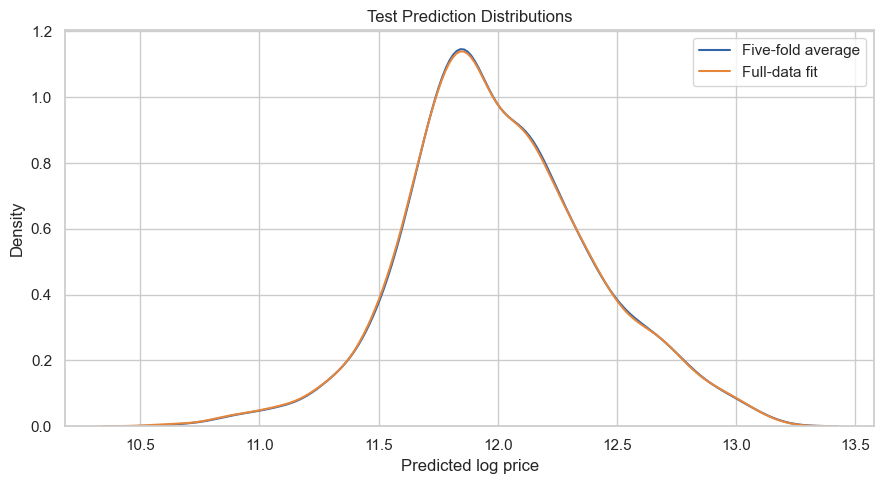

Additional full-data file: submission_full_data_lasso30_catboost40_xgboost30.csv


In [22]:
# Use the outlier policy selected by Full OOF validation.
if selected_excluded_rows is None:
    full_fit_index = np.arange(len(train))
else:
    full_fit_index = np.flatnonzero(~selected_excluded_rows.to_numpy())

weight_names = ["LASSO", "Gradient Boosting", "CatBoost", "XGBoost", "RBF SVR"]
selected_weights = dict(zip(weight_names, ensemble_weights[internal_candidate_name]))
full_component_predictions = {}

if selected_weights["LASSO"] > 0 or selected_weights["RBF SVR"] > 0:
    full_linear_preprocessor = build_preprocessor(X_linear)
    X_linear_full = full_linear_preprocessor.fit_transform(X_linear.iloc[full_fit_index])
    X_linear_test_ready = full_linear_preprocessor.transform(X_linear_test)

    if selected_weights["LASSO"] > 0:
        full_lasso_model = make_lasso(CV_SEED)
        full_lasso_model.fit(X_linear_full, y_log[full_fit_index])
        full_component_predictions["LASSO"] = full_lasso_model.predict(X_linear_test_ready)

    if selected_weights["RBF SVR"] > 0:
        full_svr_model = make_svr(CV_SEED)
        full_svr_model.fit(X_linear_full, y_log[full_fit_index])
        full_component_predictions["RBF SVR"] = full_svr_model.predict(X_linear_test_ready)

if selected_weights["Gradient Boosting"] > 0 or selected_weights["XGBoost"] > 0:
    full_tree_preprocessor = build_preprocessor(X_tree)
    X_tree_full = full_tree_preprocessor.fit_transform(X_tree.iloc[full_fit_index])
    X_tree_test_ready = full_tree_preprocessor.transform(X_tree_test)

    if selected_weights["Gradient Boosting"] > 0:
        full_gb_model = make_gradient_boosting(CV_SEED)
        full_gb_model.fit(X_tree_full, y_log[full_fit_index])
        full_component_predictions["Gradient Boosting"] = full_gb_model.predict(X_tree_test_ready)

    if selected_weights["XGBoost"] > 0:
        full_xgb_model = make_xgboost(CV_SEED)
        full_xgb_model.fit(X_tree_full, y_log[full_fit_index])
        full_component_predictions["XGBoost"] = full_xgb_model.predict(X_tree_test_ready)

if selected_weights["CatBoost"] > 0:
    full_cat_data, full_cat_columns = prepare_catboost_data(X_tree)
    full_cat_test, _ = prepare_catboost_data(X_tree_test)
    full_cat_model = CatBoostRegressor(
        iterations=1400,
        learning_rate=0.025,
        depth=5,
        l2_leaf_reg=5,
        random_strength=0.5,
        loss_function="RMSE",
        random_seed=CV_SEED,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )
    full_cat_model.fit(
        full_cat_data.iloc[full_fit_index], y_log[full_fit_index],
        cat_features=full_cat_columns,
    )
    full_component_predictions["CatBoost"] = full_cat_model.predict(full_cat_test)

full_data_test_log = sum(
    selected_weights[name] * prediction
    for name, prediction in full_component_predictions.items()
)

full_data_submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": np.expm1(full_data_test_log).clip(min=1),
})
full_data_filename = candidate_files[internal_candidate_name].replace(
    "submission_", "submission_full_data_", 1
)
full_data_path = SUBMISSION_DIR / full_data_filename
full_data_submission.to_csv(full_data_path, index=False)

fold_average_price = np.expm1(internal_candidate_test_log)
full_data_price = np.expm1(full_data_test_log)
test_prediction_comparison = pd.DataFrame({
    "Measure": [
        "Correlation on log scale",
        "Mean absolute log difference",
        "Median absolute dollar difference",
        "Maximum absolute percentage difference",
    ],
    "Value": [
        np.corrcoef(internal_candidate_test_log, full_data_test_log)[0, 1],
        np.abs(internal_candidate_test_log - full_data_test_log).mean(),
        np.median(np.abs(fold_average_price - full_data_price)),
        100 * np.max(np.abs(full_data_price / fold_average_price - 1)),
    ],
})
display(test_prediction_comparison)

full_data_file_check = pd.DataFrame({
    "Check": ["Rows", "Columns", "Missing prices", "Non-positive prices"],
    "Result": [
        len(full_data_submission),
        ", ".join(full_data_submission.columns),
        full_data_submission["SalePrice"].isna().sum(),
        (full_data_submission["SalePrice"] <= 0).sum(),
    ],
})
display(full_data_file_check)

plt.figure(figsize=(9, 5))
sns.kdeplot(internal_candidate_test_log, label="Five-fold average", color=BLUE)
sns.kdeplot(full_data_test_log, label="Full-data fit", color=ORANGE)
plt.xlabel("Predicted log price")
plt.ylabel("Density")
plt.title("Test Prediction Distributions")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "15_full_data_fit_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

test_prediction_comparison.to_csv(
    OUTPUT_DIR / "fold_average_vs_full_data_fit.csv", index=False
)
print(f"Additional full-data file: {full_data_filename}")

**How to read this comparison.** A high correlation means the two training methods agree on the general price pattern. The difference measures show how much individual predictions changed. They do not show which method is more accurate because the test prices are unknown.

The full-data result remains separate from the OOF-ranked candidates.

## 15. Final conclusion

The data review showed that many NA values describe an absent feature rather than an unknown value. EDA also identified a right-skewed target, skewed numerical predictors, meaningful zero values and strong relationships between price, quality and usable area. These findings led to meaning-based missing-value treatment, log transformation and a small group of interpretable engineered features.

Linear Regression provided the baseline, while Ridge and LASSO met the required regularized-model comparison. LASSO performed better than Ridge. Random Forest, XGBoost, ElasticNet, SVR, Gradient Boosting and CatBoost were then tested with the same five folds. Residual analysis supported combining LASSO with tree-based models because their errors were not identical.

The 30% LASSO, 40% CatBoost and 30% XGBoost ensemble produced the lowest Full OOF Log-RMSE of 0.11575. Strategies below 0.120 were retained as candidate prediction files. The full-data fit was kept as a separate experiment because it does not have an OOF estimate.

**Sources:** Kaggle competition and evaluation page; `data_description.txt`; [De Cock (2011), *Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project*](https://doi.org/10.1080/10691898.2011.11889627).